## Trabajo Práctico
### Modelo de clasificación
#### Aprendizaje Automático I

Estudiantes:
- Ruiz, Irma Carolina
- Quispe, Rocio

**Carga de librerías iniciales**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

**Carga de datos**

In [3]:
data = pd.read_csv('weatherAUS.csv')

### Análisis Exploratorio de Datos

In [4]:
data.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

**Variables Generales**
- Date: Fecha de la observación.
- Location: La ubicación o ciudad en Australia.

**Variables de Temperatura, en °C**
- MinTemp: Temperatura mínima del día.
- MaxTemp: Temperatura máxima del día.
- Temp9am: Temperatura registrada a las 9 de la mañana.
- Temp3pm: Temperatura registrada a las 3 de la tarde.

**Variables de Precipitación y Humedad**
- Rainfall: La cantidad de lluvia registrada ese día, en mm.
- Evaporation: Evaporación de agua de "Clase A" en las 24 horas hasta las 9 am, en milímetros (mm).
- Sunshine: El número de horas de sol brillante durante el día.
- Humidity9am: La humedad relativa a las 9 de la mañana, como un porcentaje.
- Humidity3pm: La humedad relativa a las 3 de la tarde, como un porcentaje.
- RainToday: Indica si hubo precipitación (más de 1 mm) en ese día, o no.

**Variables de Viento**
- WindGustDir: La dirección de la ráfaga de viento más fuerte del día (ej. N, S, SW).
- WindGustSpeed: La velocidad de la ráfaga de viento más fuerte del día, en km/h.
- WindDir9am: La dirección del viento a las 9 de la mañana.
- WindDir3pm: La dirección del viento a las 3 de la tarde.
- WindSpeed9am: La velocidad promedio del viento, a las 9 de la mañana, en km/h.
- WindSpeed3pm: La velocidad promedio del viento a las 3 de la tarde, en km/h.

**Variables Atmosféricas**
- Pressure9am: La presión atmosférica a nivel del mar a las 9 de la mañana, medida en hectopascales (hPa).
- Pressure3pm: La presión atmosférica a las 3 de la tarde, en hPa.
- Cloud9am: La fracción del cielo cubierta por nubes a las 9 de la mañana. Se mide en "oktas", una escala de 0 (cielo completamente despejado) a 8 (cielo completamente cubierto).
- Cloud3pm: La fracción del cielo cubierta por nubes a las 3 de la tarde.

**Variable Objetivo**

*RainTomorrow*: Variable categórica ('Yes'/'No') que responde a la pregunta: "¿Llovió al día siguiente?".

Para agilizar la limpieza, se verifica si hay registros con solo valores nulos.

In [6]:
data.isna().all(axis=1).any()

False

No hay registros solo con datos nulos. Se verifica cuáles tienen nulos y qué porcentaje representa del total.

In [7]:
porc_nulos = data.isnull().sum()/len(data)*100
col_nulos = porc_nulos[porc_nulos>0].sort_values(ascending=False)

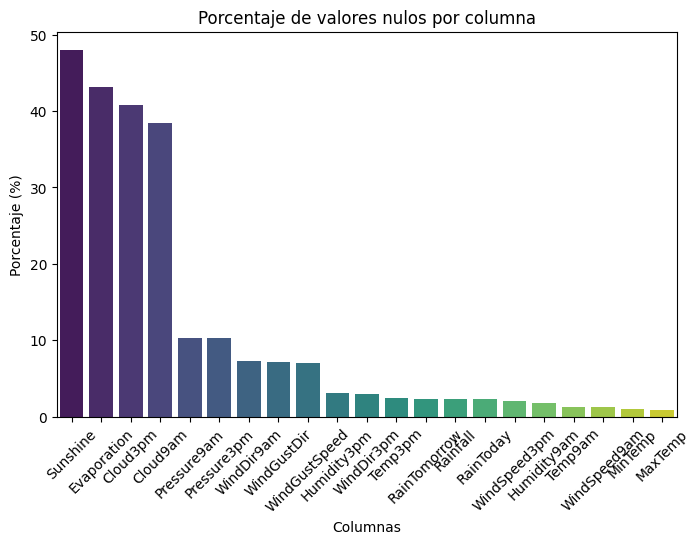

In [8]:
plt.figure(figsize=(8,5))
sns.barplot(x=col_nulos.index, y=col_nulos.values, palette='viridis')

plt.title('Porcentaje de valores nulos por columna')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Columnas')
plt.xticks(rotation=45)
plt.show()

Distribución de datos numéricos en histogramas y outliers.

In [9]:
data_num = data[['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 
                 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
                 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']]

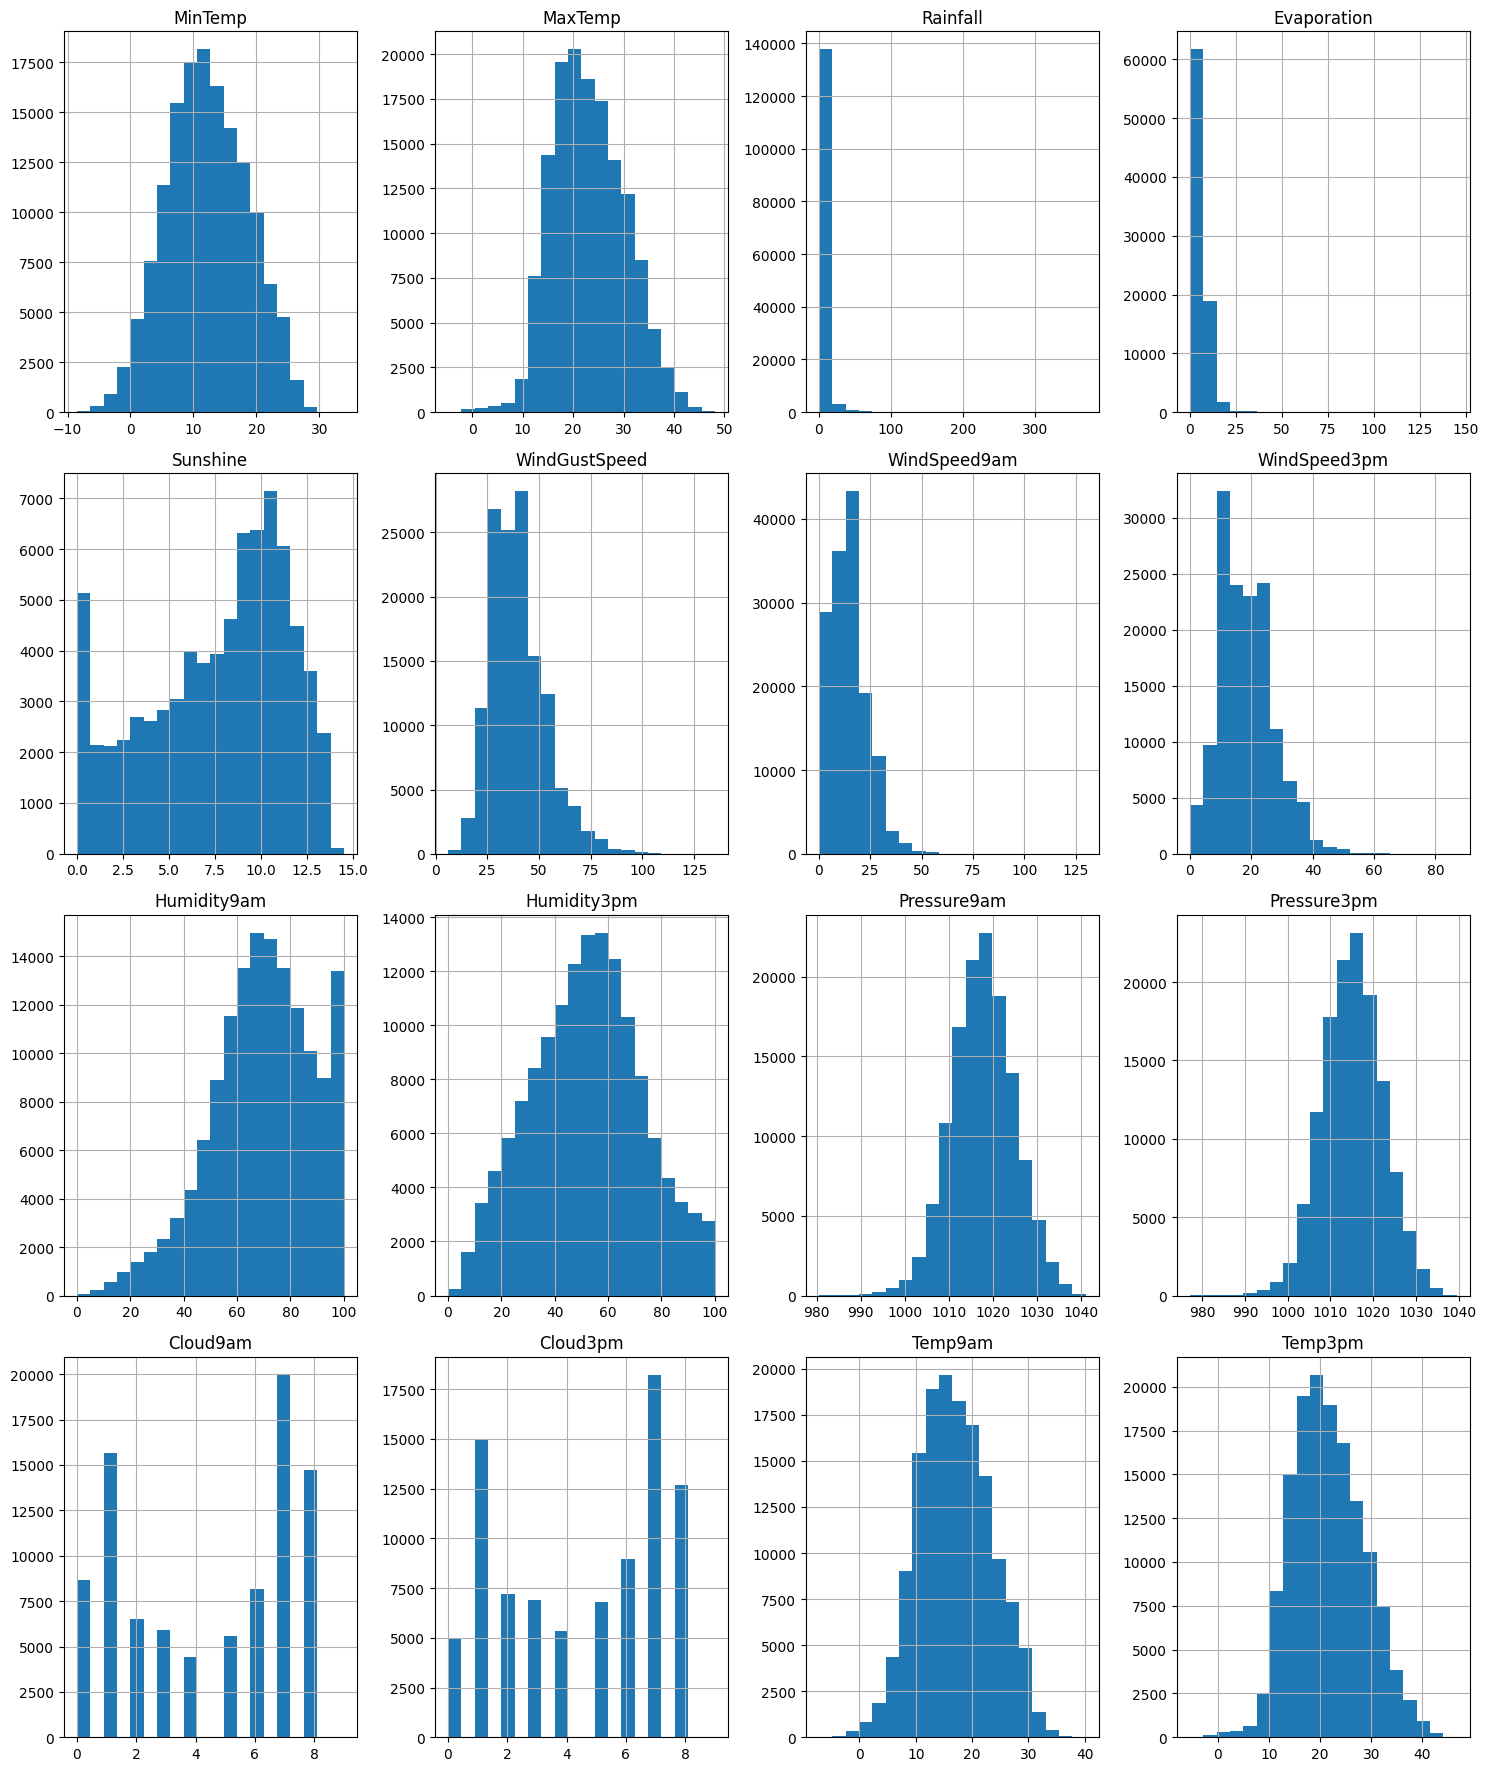

In [10]:
data_num.hist(figsize=(15, 22), bins=20, layout=(5, 4))
plt.tight_layout()
plt.show()

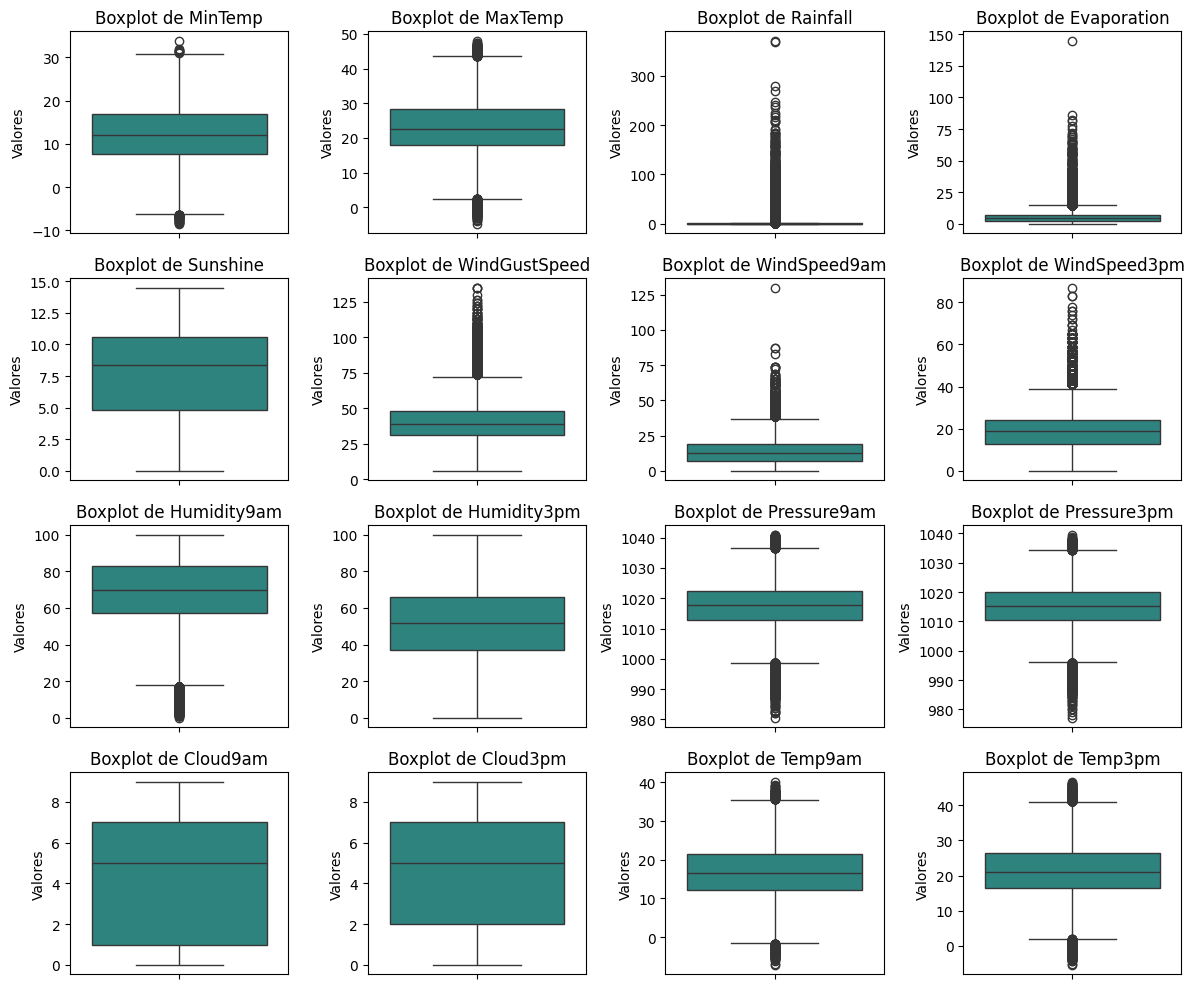

In [11]:
columnas = data_num.columns

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(columnas):
    sns.boxplot(y=data_num[col], ax=axes[i], palette='viridis')
    axes[i].set_title(f'Boxplot de {col}')
    axes[i].set_ylabel('Valores')

plt.tight_layout()
plt.show()

**Grupo de Temperaturas (MinTemp, MaxTemp, Temp9am, Temp3pm)**

Todas las variables de temperatura muestran distribuciones bastante simétricas. MaxTemp es casi perfectamente simétrica. MinTemp, en cambio, tiene una ligera asimetría izquierda (cola izquierda), con varios outliers en el extremo frío. Esto sugiere que las temperaturas mínimas inusualmente bajas son más comunes que las máximas inusualmente altas.

Temp9am vs Temp3pm: Ambas son muy simétricas, parecidas a MaxTemp. Tienen outliers en ambos extremos, lo cual es normal para mediciones de temperatura.

**Grupo de Humedad (Humidity9am, Humidity3pm)**

Humidity9am: Muestra una fuerte asimetría izquierda. La "caja" está aplastada en la parte superior del gráfico, lo que significa que la mayoría de las mañanas la humedad es muy alta (entre 70% y 90%). Los outliers son todos valores bajos.

Humidity3pm: Es la variable más simétrica y "limpia" de todas. Tiene una distribución casi normal, centrada alrededor del 50%-60%, y casi sin outliers.

Los datos muestran un patrón: la humedad es alta y poco variable por la mañana, pero baja y se "normaliza" por la tarde.

**Grupo de Presión Atmosférica (Pressure9am, Pressure3pm)**

Ambas presentan una clara asimetría izquierda. La mediana está en la mitad superior de la caja, y el bigote inferior es mucho más largo. Ambas tienen una fuerte presencia de outliers en el extremo inferior.

**Grupo de Viento (WindGustSpeed, WindSpeed9am, WindSpeed3pm)**

Todas tienen una fuerte asimetría derecha (cola derecha). La "caja" está comprimida en valores bajos, lo que indica que la mayoría del tiempo el viento es leve. Todas tienen una enorme cantidad de outliers en el extremo superior. Esos outliers representan los días de viento o ráfagas fuertes.

9am vs 3pm: La mediana y la caja de WindSpeed3pm están ligeramente más altas que en WindSpeed9am, sugiriendo que, en general, hay más viento por la tarde.

**Grupo de Agua (Rainfall, Evaporation)**

Rainfall: La "caja" (el 50% central de los datos) es una línea plana en cero. Esto significa que al menos el 75% de los días no llueve nada. Los outliers son la lluvia.

Evaporation: Similar a Rainfall, la caja está totalmente comprimida en la parte inferior. La mayoría de los valores son muy bajos.

**Grupo de Cielo (Sunshine, Cloud9am, Cloud3pm)**

Sunshine: distribución bimodal. La caja está aplastada en la parte superior (días de mucho sol), y el bigote inferior se extiende hasta 0 (días sin sol).

Cloud9am y Cloud3pm: No tienen outliers y los bigotes se extienden por todo el rango (de 0 a 8 o 9).

Detalle a tener en cuenta: Cloud9am y Cloud3pm son variables discretas (probablemente "octas" de cielo cubierto, de 0 a 8).


Detalles sobre las columnas categóricas.

In [12]:
data_cat = data[['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']]

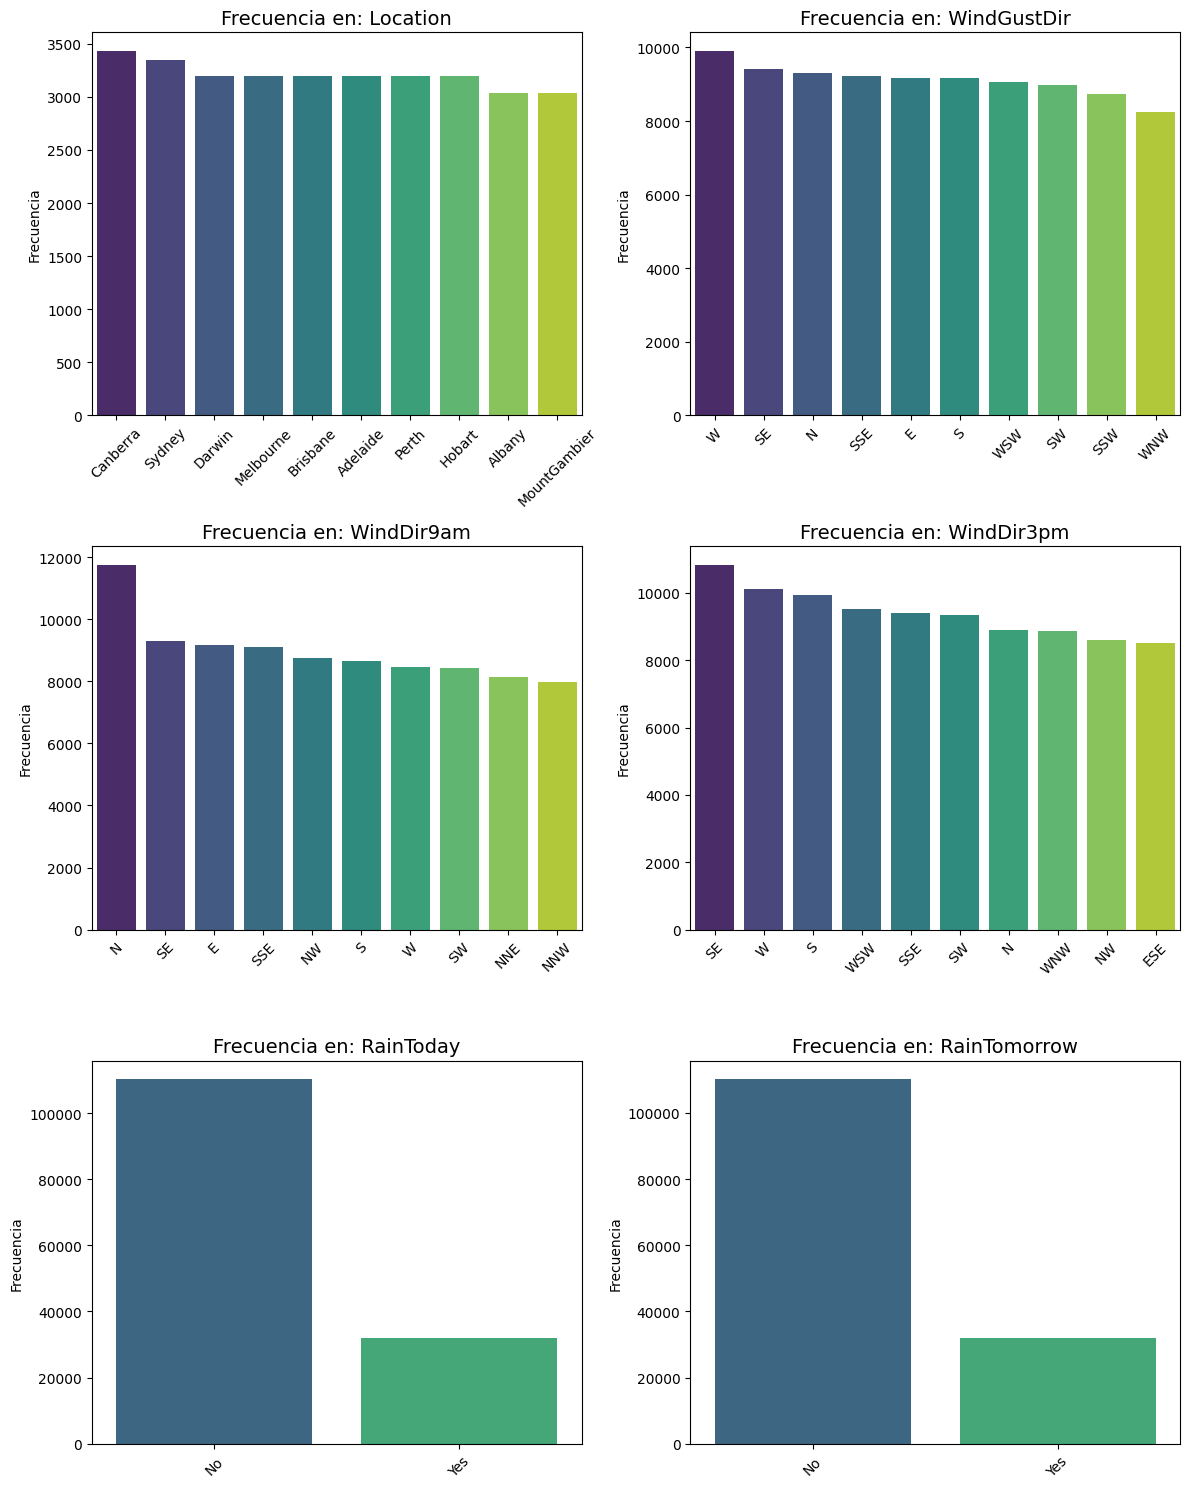

In [13]:
import math

n_cols = 2
n_rows = math.ceil(data_cat.shape[1] / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(12, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(data_cat.columns):
    top_cat = data_cat[col].value_counts().nlargest(10)
    
    sns.barplot(x=top_cat.index, y=top_cat.values, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Frecuencia en: {col}', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Las variables categóricas relacionadas a WindDir y WindGus se dividen en los puntos cardinales de los cuales provienen los vientos. No parece hacer categorías sin valores. Por otro lado, las variables relacionadas a Rain solo tienen dos categorías que podrían ser transformadas en numéricas 1/0 para su uso en un modelo predictivo.

En este sentido, ya que **RainTomorrow** va a ser la variable objetivo, se puede suponer que está desbalanceada al haber más datos de 'No' que de 'Yes'. Esto indica que posiblemente deberá trabajarse para que no afecte a las predicciones.

---

### División del dataset en train-val-test

In [14]:
from sklearn.model_selection import train_test_split

Teniendo en cuenta el análisis sobre los datos nulos por columna visto previamente, se resuelve que imputar a las columnas que tienen 40% o más de nulos, no tiene sentido. Por lo tanto, se eliminarán de las variables predictoras (X). Asimismo, solo se eliminarán 3267 registros nulos de 'RainTomorrow' (futura variable objetivo) para que no cause problemas en el split. Esto representaría el apróx. 2,25% de los registros del dataset original.

In [15]:
data['RainTomorrow'].isna().sum()

3267

In [16]:
data = data.dropna(subset=['RainTomorrow'])

In [17]:
X = data.drop(columns=['RainTomorrow', 'Sunshine', 'Evaporation', 'Cloud3pm', 'Cloud9am'], axis=1)
Y = data['RainTomorrow']

In [18]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,
    random_state=42,
    stratify=y_train_val)

# Proporción final: X_train: 60%, X_val: 20%, X_test: 20%

In [19]:
print(f"""Conjunto de entrenamiento: x_train: {X_train.shape}, y_train: {y_train.shape[0]}
Conjunto de validación: x_val: {X_val.shape}, y_val: {y_val.shape[0]}
Conjunto de prueba: x_test: {X_test.shape}, y_test: {y_test.shape[0]}""")

Conjunto de entrenamiento: x_train: (85315, 18), y_train: 85315
Conjunto de validación: x_val: (28439, 18), y_val: 28439
Conjunto de prueba: x_test: (28439, 18), y_test: 28439


Se transforman los valores de la variable objetivo y RainToday en formato numérico para facilitar el funcionamiento del futuro modelo.

In [20]:
y_train = y_train.replace({'Yes': 1, 'No': 0}).astype(int)
y_val = y_val.replace({'Yes': 1, 'No': 0}).astype(int)
y_test = y_test.replace({'Yes': 1, 'No': 0}).astype(int)

In [21]:
if 'RainToday' in X_train.columns and X_train['RainToday'].dtype == 'object':
    dic = {'Yes': 1, 'No': 0}
    X_train['RainToday'] = X_train['RainToday'].map(dic)
    X_val['RainToday'] = X_val['RainToday'].map(dic)
    X_test['RainToday'] = X_test['RainToday'].map(dic)

---

### Imputación de datos faltantes y transformación de datos

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn import set_config

In [24]:
set_config(transform_output="pandas")

Se aplica una transformación logarítmica (específicamente np.log1p) a las variables WindGustSpeed, WindSpeed9am, WindSpeed3pm y Rainfall. Esta decisión se basa en el EDA, el cual reveló que dichas variables poseían una fuerte asimetría positiva (cola a la derecha).

In [27]:
cols_transf_log = ['WindGustSpeed', 'WindSpeed9am', 
                   'WindSpeed3pm', 'Rainfall']

for df in [X_train, X_val, X_test]:
    df[cols_transf_log] = df[cols_transf_log].clip(lower=0)  # si el valor es menor que 0 queda como 0 sino queda igual
    df[cols_transf_log] = np.log1p(df[cols_transf_log])

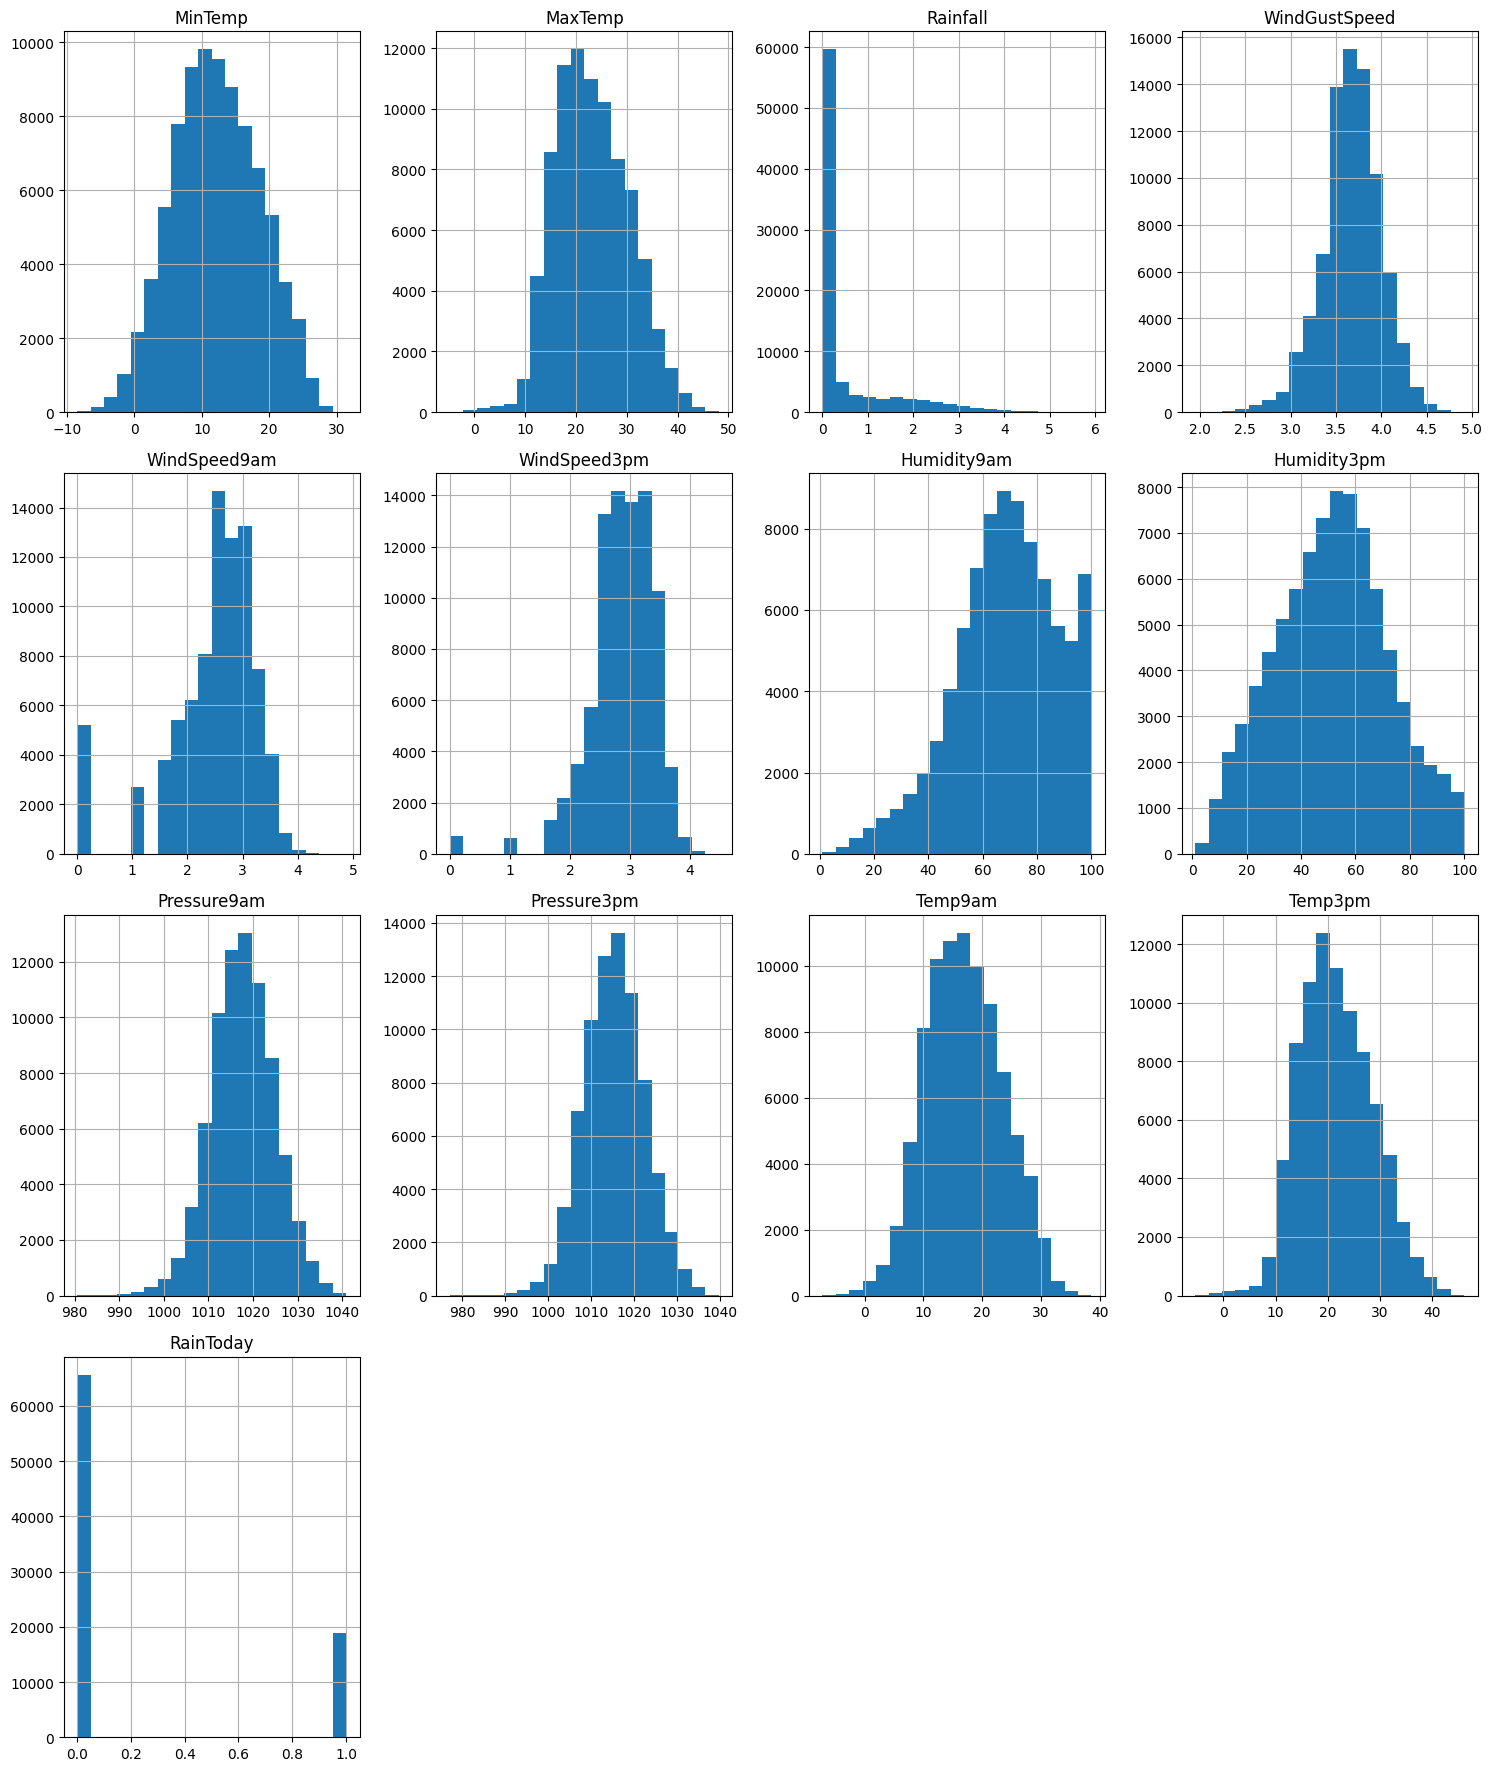

In [28]:
X_train.hist(figsize=(15, 22), bins=20, layout=(5, 4))
plt.tight_layout()
plt.show()

Aunque Rainfall y las velocidades del viento tienen un sesgo positivo luego del escalado robusto, el comportamiento es inherente al fenómeno meteorológico y no representa una deficiencia del preprocesamiento. Las transformaciones aplicadas reducen la influencia de valores extremos sin eliminar información relevante.

Las distribuciones de las variables de viento (WindGustSpeed, etc.) se volvieron mucho más simétricas y centradas. En Rainfall, aunque se mantiene una gran cantidad de ceros, el impacto de los valores extremos de lluvia fue drásticamente reducido, agrupándolos en un rango mucho más manejable.

---

### Creación de variables e imputaciones finales
Se chequea cómo quedó el dataset hasta esta instancia. A continuación, se procede a crear variables nuevas desde Date y dummies sobre todas las variables categóricas.

In [29]:
X_train.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,RainToday
76253,2012-07-27,Portland,10.3,12.2,1.722767,S,3.737670,S,SW,2.995732,3.044522,71.0,62.0,1016.6,1017.3,10.8,10.7,1.0
73930,2014-08-11,Nhil,-0.4,11.9,0.000000,SSE,3.526361,SSW,S,2.079442,2.639057,91.0,46.0,1032.9,1030.8,2.4,11.2,0.0
24746,2010-08-12,Penrith,10.5,17.5,0.182322,WSW,3.850148,W,SW,2.772589,3.295837,49.0,44.0,NaN,NaN,14.2,16.0,0.0
82735,2014-01-01,Dartmoor,15.0,24.2,0.000000,NW,3.970292,NNW,NW,2.772589,3.044522,23.0,99.0,1005.1,1002.4,24.1,21.1,0.0
24838,2010-11-12,Penrith,16.0,33.2,0.182322,ENE,3.583519,SSW,NE,1.945910,2.772589,73.0,32.0,NaN,NaN,22.1,32.6,0.0


Se crea season para solo guiar al modelo por la temporada por meses.

In [30]:
estaciones = {
    12: 'Verano', 1: 'Verano', 2: 'Verano',
    3: 'Otoño', 4: 'Otoño', 5: 'Otoño',
    6: 'Invierno', 7: 'Invierno', 8: 'Invierno',
    9: 'Primavera', 10: 'Primavera', 11: 'Primavera'}

In [31]:
for conj in [X_train, X_val, X_test]:
    conj['Date'] = pd.to_datetime(conj['Date'])

    conj['season'] = conj['Date'].dt.month.map(estaciones)
    conj.drop(columns=['Date'], inplace=True)

Las variables de vientos y season pasan a ser dummies en todos los conjuntos.

In [32]:
from sklearn.preprocessing import OneHotEncoder

In [33]:
cols_categ = ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'season']
for df in [X_train, X_val, X_test]:
    df[cols_categ] = df[cols_categ].astype(str)

In [34]:
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore') 
ohe.fit(X_train[cols_categ])

OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

In [35]:
ohe_nombres = ohe.get_feature_names_out(cols_categ)

data_final_list = []

for df in [X_train, X_val, X_test]:
    cols_enc = ohe.transform(df[cols_categ])

    data_ohe = pd.DataFrame(cols_enc, columns=ohe_nombres, index=df.index)

    data_procesada = df.drop(columns=cols_categ)

    data_final = pd.concat([data_procesada, data_ohe], axis=1)
    data_final_list.append(data_final)

In [36]:
X_train = data_final_list[0]
X_val = data_final_list[1]
X_test = data_final_list[2]

Se continúa con la normalización de la variable Location, ya que es muy importante para asegurarse que solo se trabajará con ciudades de Australia.

In [37]:
from geonamescache import GeonamesCache

In [38]:
gc = GeonamesCache()

def coords_aus(nombre_ciudad):
    """
    Busca una ciudad por su nombre y devuelve las coordenadas
    solo si se encuentra en Australia (countrycode 'AU').
    """
    posibles_ciudades = gc.get_cities_by_name(nombre_ciudad)
    
    for dict_ciudad in posibles_ciudades:
        data_ciudad = list(dict_ciudad.values())[0] 
        
        if data_ciudad['countrycode'] == 'AU':
            return (data_ciudad['latitude'], data_ciudad['longitude'])
    
    return None

In [39]:
ciudades_unicas = X_train['Location'].unique()
coord_map = {ciudad: coords_aus(ciudad) for ciudad in ciudades_unicas}

In [40]:
for df in [X_train, X_val, X_test]:
    df['coords'] = df['Location'].map(coord_map)
    
    df['latitude'] = df['coords'].apply(lambda x: x[0] if x is not None else None)
    df['longitude'] = df['coords'].apply(lambda x: x[1] if x is not None else None)
    df.drop(columns=['coords'], inplace=True)

Visualización de ciudades en mapa

In [41]:
import geopandas as gpd
import contextily as ctx

In [42]:
def crear_geodf(df, lon_col="longitude", lat_col="latitude"):
    """
    Convierte un DataFrame con columnas de latitud/longitud
    en un GeoDataFrame en proyección métrica (EPSG:3857)
    """
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df[lon_col], df[lat_col]),
        crs="EPSG:4326"  # coordenadas geográficas
    )
    return gdf.to_crs(epsg=3857)

In [43]:
gdf_train = crear_geodf(X_train)

In [44]:
def graf_mapa(geodf, titulo):
    fig, ax = plt.subplots(figsize=(10, 8))
    geodf.plot(ax=ax, color='red', markersize=60)

    # Mapa base
    ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

    ax.set_xlim(geodf.total_bounds[0] - 1e6, geodf.total_bounds[2] + 1e6)
    ax.set_ylim(geodf.total_bounds[1] - 1e6, geodf.total_bounds[3] + 1e6)

    ax.set_title(titulo, fontsize=14)
    plt.show()

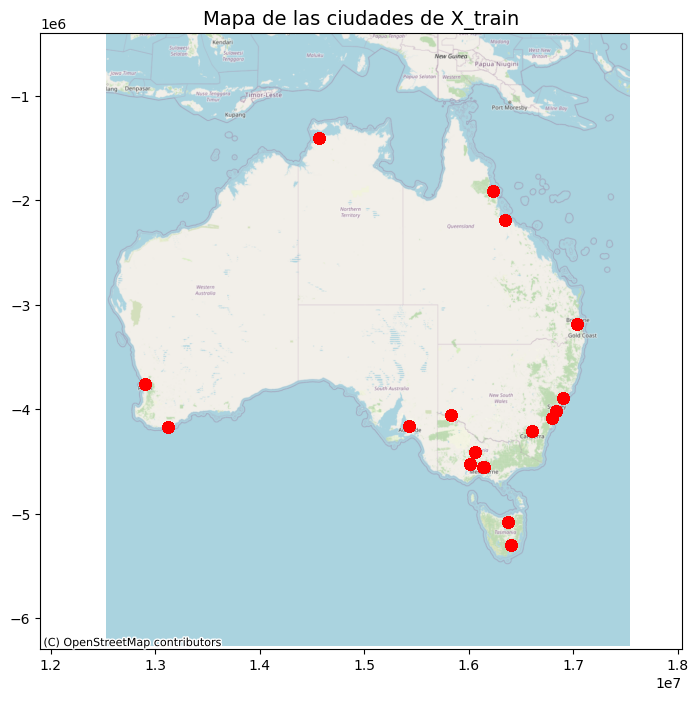

In [45]:
titulo = 'Mapa de las ciudades de X_train'
graf_mapa(gdf_train, titulo)

Si bien el mapa graficó las ciudades sin aparentes problemas, se verifica si hay datos nulos entre las coordenadas de ciudades.

In [46]:
X_train[['Location', 'latitude', 'longitude']]

,Location,latitude,longitude
76253,Portland,NaN,NaN
73930,Nhil,NaN,NaN
24746,Penrith,NaN,NaN
82735,Dartmoor,NaN,NaN
24838,Penrith,NaN,NaN
...,...,...,...
37918,WaggaWagga,NaN,NaN
68249,Melbourne,-37.81400,144.96332
81886,Dartmoor,NaN,NaN
85314,Brisbane,-27.46794,153.02809


Sí hay ciudades que no fueron encontradas en la función que debía ubicar sus coordenadas. Se corrije de manera manual.

In [47]:
ciudades_faltantes = X_train[X_train['latitude'].isnull()]['Location'].unique()
ciudades_faltantes

array(['Portland', 'Nhil', 'Penrith', 'Dartmoor', 'MountGinini',
       'CoffsHarbour', 'Nuriootpa', 'Sale', 'Cobar', 'Albury',
       'SalmonGums', 'Watsonia', 'BadgerysCreek', 'GoldCoast',
       'NorfolkIsland', 'PerthAirport', 'SydneyAirport', 'Moree',
       'PearceRAAF', 'Woomera', 'Tuggeranong', 'NorahHead', 'Walpole',
       'MelbourneAirport', 'MountGambier', 'WaggaWagga', 'Katherine',
       'Witchcliffe', 'AliceSprings', 'Williamtown', 'Uluru'],
      dtype=object)

In [48]:
coord_map = {
    # Ciudades que ya funcionaban
    'Melbourne': (-37.81400, 144.96332),
    'Brisbane': (-27.46794, 153.02809),
    'Perth': (-31.95224, 115.8614),
    # --- Ciudades que faltaban ---
    'Portland': (-38.3398, 141.6032),
    'Nhil': (-36.3333, 141.6500),
    'Penrith': (-33.7510, 150.6940),
    'Dartmoor': (-37.9220, 141.2742),
    'MountGinini': (-35.5297, 148.7750),
    'CoffsHarbour': (-30.2963, 153.1140),
    'Nuriootpa': (-34.4699, 138.9950),
    'Sale': (-38.1042, 147.0667),
    'Cobar': (-31.4983, 145.8344),
    'Albury': (-36.0737, 146.9135),
    'SalmonGums': (-32.9806, 121.6444),
    'Watsonia': (-37.7120, 145.0830),
    'BadgerysCreek': (-33.8887, 150.7403),
    'GoldCoast': (-28.0167, 153.4000),
    'NorfolkIsland': (-29.0408, 167.9547),
    'PerthAirport': (-31.9403, 115.9669),
    'SydneyAirport': (-33.9399, 151.1753),
    'Moree': (-29.4632, 149.8431),
    'PearceRAAF': (-31.6739, 116.0150),
    'Woomera': (-31.2010, 136.8340),
    'Tuggeranong': (-35.4211, 149.0961),
    'NorahHead': (-33.2819, 151.5714),
    'Walpole': (-34.9750, 116.7306),
    'MelbourneAirport': (-37.6733, 144.8433),
    'MountGambier': (-37.8290, 140.7798),
    'WaggaWagga': (-35.1189, 147.3694),
    'Katherine': (-14.4647, 132.2639),
    'Witchcliffe': (-34.0261, 115.1017),
    'AliceSprings': (-23.6980, 133.8807),
    'Williamtown': (-32.8150, 151.8425),
    'Uluru': (-25.3444, 131.0369)
}

In [49]:
lat_map = {city: coords[0] for city, coords in coord_map.items()}
lon_map = {city: coords[1] for city, coords in coord_map.items()}


for df in [X_train, X_val, X_test]:
    idx_nulos = df['latitude'].isnull()
    df.loc[idx_nulos, 'latitude'] = df.loc[idx_nulos, 'Location'].map(lat_map)
    df.loc[idx_nulos, 'longitude'] = df.loc[idx_nulos, 'Location'].map(lon_map)

In [50]:
X_train[['latitude', 'longitude']].isnull().sum()

latitude     0
longitude    0
dtype: int64

Se continúa con la clusterización de las regiones. Se hipotetiza que se podría dividir el mapa en cuatro regiones (norte, sur, este y oeste) pero se verificará con el método del codo.

In [51]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [52]:
from sklearn.cluster import KMeans

In [53]:
x = X_train[['latitude', 'longitude']]

d:\Programas\anaconda3\envs\Python_ML\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


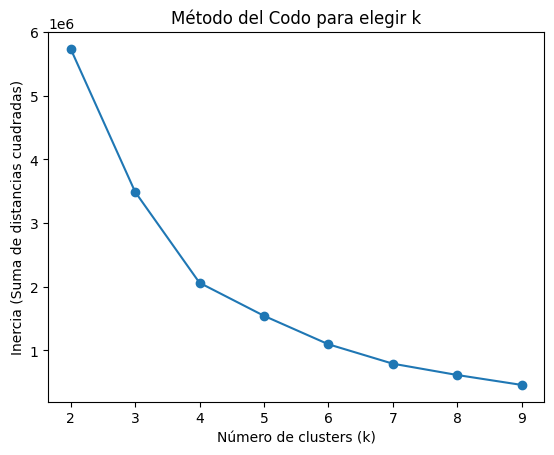

In [54]:
inertias = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(x)
    inertias.append(km.inertia_)

plt.plot(range(2, 10), inertias, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia (Suma de distancias cuadradas)')
plt.title('Método del Codo para elegir k')
plt.show()

El método del codo demuestra que es mejor 6 que 4. Se graficará esta idea.

In [55]:
k = 6
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

X_train['region_cluster'] = kmeans.fit_predict(x)
X_val['region_cluster'] = kmeans.predict(X_val[['latitude', 'longitude']])
X_test['region_cluster'] = kmeans.predict(X_test[['latitude', 'longitude']])

Graficación de resultados de clusters

In [56]:
gdf = crear_geodf(X_train)

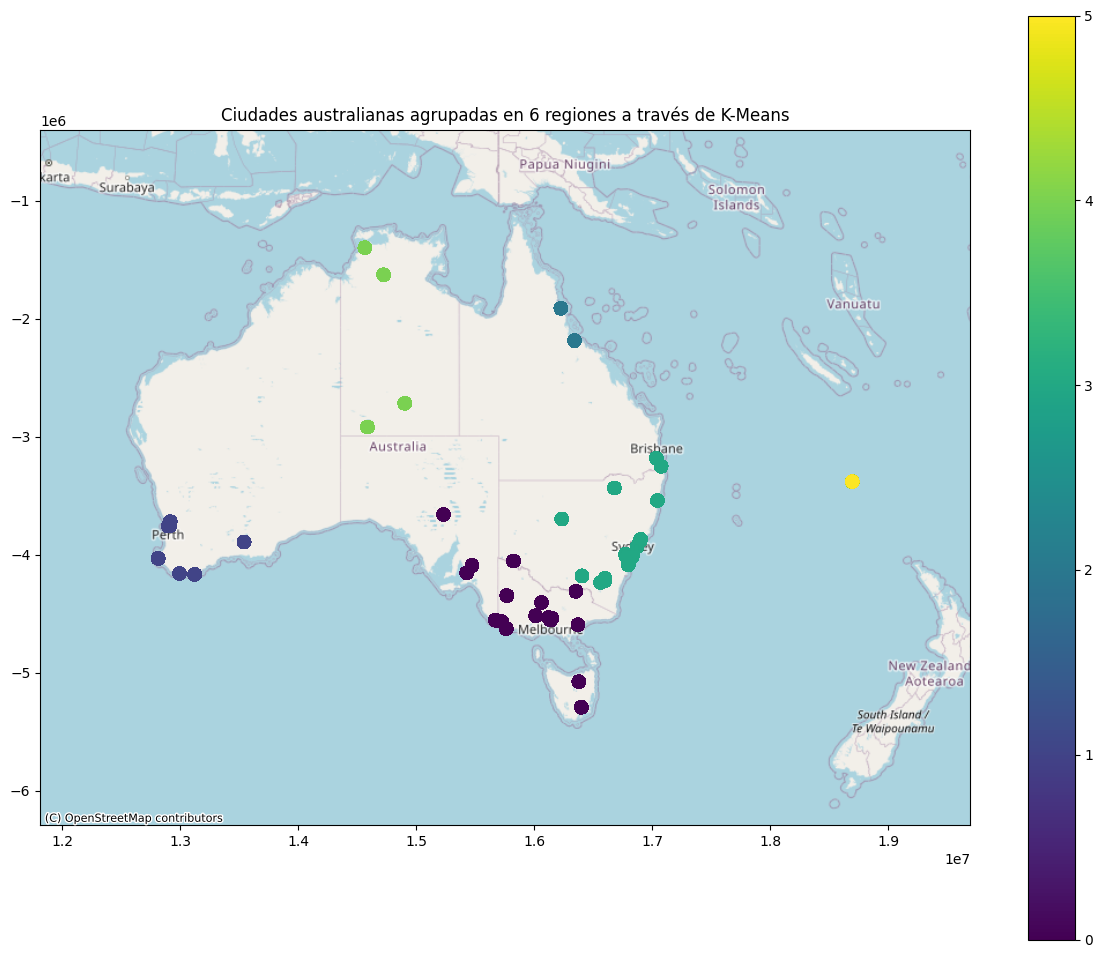

In [57]:
fig, ax = plt.subplots(figsize=(15, 12))
gdf.plot(ax=ax, column="region_cluster", legend=True, markersize=80, alpha=0.9)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.set_xlim(gdf.total_bounds[0] - 1e6, gdf.total_bounds[2] + 1e6)
ax.set_ylim(gdf.total_bounds[1] - 1e6, gdf.total_bounds[3] + 1e6)
ax.set_title(f"Ciudades australianas agrupadas en {k} regiones a través de K-Means")
plt.show()

Se eliminan las columnas que se consideran innecesarias y se procede a trabajar sobre otras potencialmente útiles que no fueron observadas, como Date. Previamente, se transformar las regiones encontradas a variables codificadas.

In [58]:
ohe_cluster = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

ohe_cluster.fit(X_train[['region_cluster']])

# Nombres de las nuevas columnas
nombres_cols_cluster = ohe_cluster.get_feature_names_out(['region_cluster'])

def aplicar_ohe_cluster(df, encoder, nombres_cols):
    matriz_ohe = encoder.transform(df[['region_cluster']])
    df_ohe = pd.DataFrame(matriz_ohe, columns=nombres_cols, index=df.index)
    df_final = pd.concat([df, df_ohe], axis=1)
    return df_final

X_train = aplicar_ohe_cluster(X_train, ohe_cluster, nombres_cols_cluster)
X_val = aplicar_ohe_cluster(X_val, ohe_cluster, nombres_cols_cluster)
X_test = aplicar_ohe_cluster(X_test, ohe_cluster, nombres_cols_cluster)

In [59]:
for df in [X_train, X_val, X_test]:
    df.drop(columns=['Location','latitude', 'longitude', 'region_cluster'], inplace=True)

Finalmente se imputan los valores nulos de las columnas que no fueron eliminadas, a través de KNN.

In [90]:
from sklearn.impute import KNNImputer

In [91]:
colum_num = ['WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Rainfall',
                  'MinTemp', 'MaxTemp', 'Humidity9am', 'Humidity3pm', 
                  'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm']
colum_cat = ['RainToday']
todas_cols = X_train.columns.tolist()

In [92]:
full_pipeline = Pipeline(steps=[
    ('scaler', RobustScaler()),              
    ('imputer', KNNImputer(n_neighbors=6))])

X_train = full_pipeline.fit_transform(X_train[todas_cols])
X_val = full_pipeline.transform(X_val[todas_cols])
X_test = full_pipeline.transform(X_test[todas_cols])

Con el fin de chequear la relación entre las variables numéricas resultantes post imputación y transformación, se verifica la correlación entre ellas. Esto permitirá eliminar columnas antes del desarrollo del modelo predictivo.

In [93]:
corr_matrix = X_train[colum_num].corr()

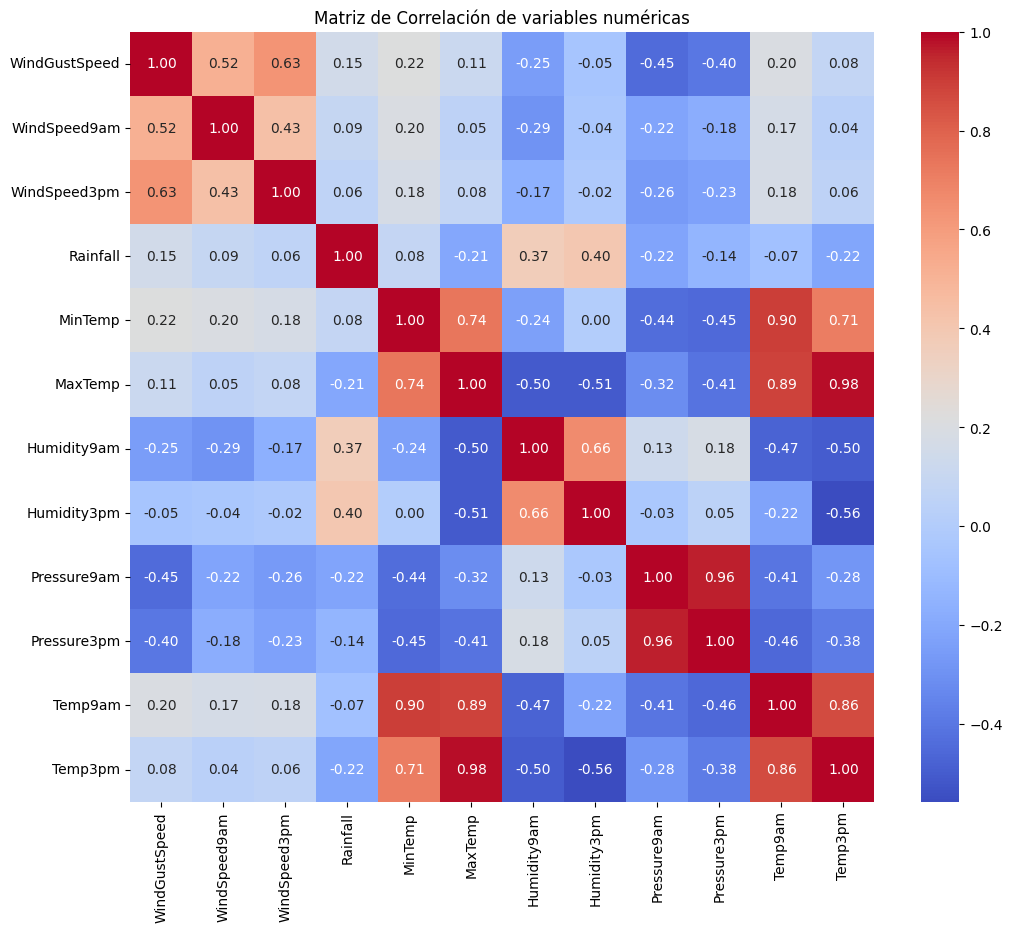

In [94]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de variables numéricas')
plt.show()

Como se observa en el anterior análisis, se encuentra mucha correlación entre 'WindSpeed3pm', 'WindGustSpeed', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'MinTemp', 'MaxTemp', 'Humidity9am', 'Humidity3pm'. Se procede a probar modelos para descartar o no, alguna de estas variables.

In [121]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.pipeline import make_pipeline

In [122]:
X_train_df = pd.DataFrame(X_train, columns=['WindSpeed3pm', 'WindGustSpeed', 'Pressure9am', 'Pressure3pm', 
                        'Temp9am', 'Temp3pm', 'MinTemp', 'MaxTemp', 'Humidity9am', 'Humidity3pm'])
X_test_df = pd.DataFrame(X_test, columns=['WindSpeed3pm', 'WindGustSpeed', 'Pressure9am', 'Pressure3pm', 
                        'Temp9am', 'Temp3pm', 'MinTemp', 'MaxTemp', 'Humidity9am', 'Humidity3pm'])

X1_train = X_train_df[['Pressure9am', 'Pressure3pm', 'Temp3pm', 'MaxTemp', 'Humidity3pm']]
X2_train = X_train_df[['MinTemp', 'MaxTemp', 'WindGustSpeed', 'WindSpeed3pm', 'Pressure9am', 'Humidity9am']]
X3_train = X_train_df[['MinTemp', 'MaxTemp', 'Pressure9am', 'Temp9am', 'WindSpeed3pm', 'Humidity3pm']]

X1_test = X_test_df[['Pressure9am', 'Pressure3pm', 'Temp3pm', 'MaxTemp', 'Humidity3pm']]
X2_test = X_test_df[['MinTemp', 'MaxTemp', 'WindGustSpeed', 'WindSpeed3pm', 'Pressure9am', 'Humidity9am']]
X3_test = X_test_df[['MinTemp', 'MaxTemp', 'Pressure9am', 'Temp9am', 'WindSpeed3pm', 'Humidity3pm']]

X5_train = X_train_df[['MinTemp', 'MaxTemp', 'Humidity9am', 'Humidity3pm', 
                             'WindGustSpeed', 'WindSpeed3pm', 'Pressure3pm']]
X5_test = X_test_df[['MinTemp', 'MaxTemp', 'Humidity9am', 'Humidity3pm', 
                             'WindGustSpeed', 'WindSpeed3pm', 'Pressure3pm']]

X4_train = X_train_df #todas las var. juntas
X4_test = X_test_df

In [123]:
modelo1 = make_pipeline(StandardScaler(), LogisticRegression()).fit(X1_train, y_train)
modelo2 = make_pipeline(StandardScaler(), LogisticRegression()).fit(X2_train, y_train)
modelo3 = make_pipeline(StandardScaler(), LogisticRegression()).fit(X3_train, y_train)
modelo4 = make_pipeline(StandardScaler(), LogisticRegression()).fit(X4_train, y_train)
modelo5 = make_pipeline(StandardScaler(), LogisticRegression()).fit(X5_train, y_train)

# predicciones en test
y_pred1 = modelo1.predict(X1_test)
y_pred2 = modelo2.predict(X2_test)
y_pred3 = modelo3.predict(X3_test)
y_pred4 = modelo4.predict(X4_test)
y_pred5 = modelo5.predict(X5_test)

# evaluación en este caso del f1 score
f1_1 = f1_score(y_test, y_pred1)
f1_2 = f1_score(y_test, y_pred2)
f1_3 = f1_score(y_test, y_pred3)
f1_4 = f1_score(y_test, y_pred4)
f1_5 = f1_score(y_test, y_pred5)

print(f"Modelo 1: F1 = {f1_1:.3f}")
print(f"Modelo 2: F1 = {f1_2:.3f}")
print(f"Modelo 3: F1 = {f1_3:.3f}")
print(f"Modelo 4 (Todas juntas): F1 = {f1_4:.3f}")
print(f"Modelo 5: F1 = {f1_5:.3f}")

Modelo 1: F1 = 0.527
Modelo 2: F1 = 0.469
Modelo 3: F1 = 0.528
Modelo 4 (Todas juntas): F1 = 0.565
Modelo 5: F1 = 0.565


Usando las variables del modelo 5, se obtuvo prácticamente el mismo rendimiento que el modelo 4 que tenía todas las variables relacionadas. Esto confirma que Pressure9am, Temp9am y Temp3pm son mayormente "ruido" cuando se tiene Pressure3pm, MinTemp y MaxTemp. Se opta por las variables del modelo 5 y rever las correlaciones.

In [124]:
for df in [X_train, X_val, X_test]:
    df.drop(columns=['Pressure9am', 'Temp9am', 'Temp3pm'], inplace=True)

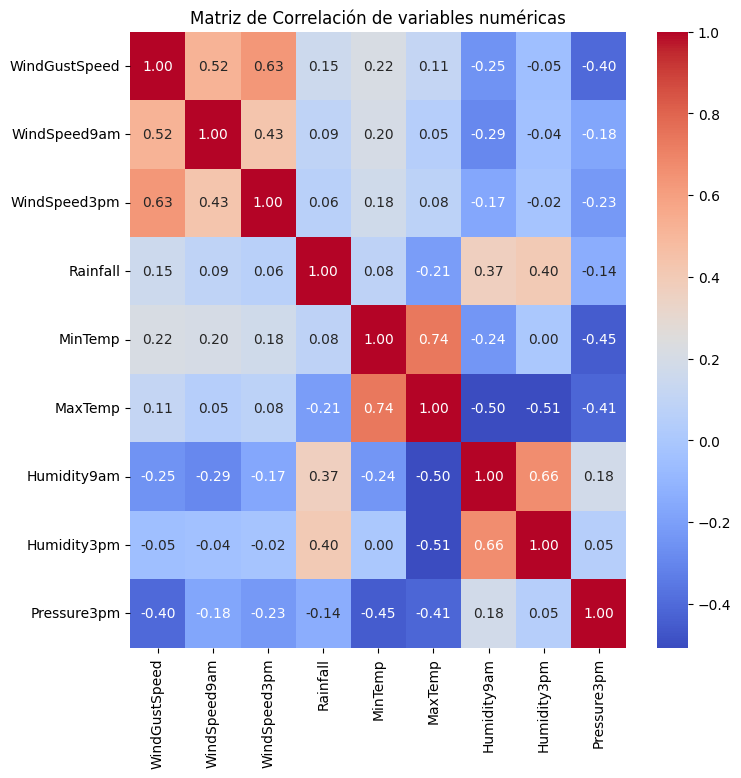

In [125]:
colum_numer_final_2 = ['WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Rainfall', 'MinTemp',
       'MaxTemp', 'Humidity9am', 'Humidity3pm', 'Pressure3pm']

corr_matrix_2 = X_train[colum_numer_final_2].corr()

plt.figure(figsize=(8, 8))
sns.heatmap(corr_matrix_2, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de variables numéricas')
plt.show()

---

### Desarrollo de Modelo de Regresión Logística

In [126]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc, PrecisionRecallDisplay, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score)
from imblearn.over_sampling import SMOTE

Escalado de variables previo al modelado.

In [128]:
cols_a_escalar = ['WindGustSpeed','WindSpeed9am', 'WindSpeed3pm', 'Rainfall',
                'MinTemp', 'MaxTemp', 'Humidity9am', 'Humidity3pm', 'Pressure3pm']

scaler = RobustScaler()

In [129]:
scaler.fit(X_train[cols_a_escalar])

X_train[cols_a_escalar] = scaler.transform(X_train[cols_a_escalar])
X_val[cols_a_escalar] = scaler.transform(X_val[cols_a_escalar])
X_test[cols_a_escalar] = scaler.transform(X_test[cols_a_escalar])

Se construye el modelo de regresión logística con algunos parámetros prefijados.

In [130]:
modelo_1 = LogisticRegression(
    C=0.1,
    random_state=42,
    class_weight='balanced')

Validación cruzada:

In [131]:
from sklearn.model_selection import cross_val_score

In [132]:
scores = cross_val_score(modelo_1, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)

print(f"F1 promedio en CV: {scores.mean():.4f}")
print(f"Desviación estándar: {scores.std():.4f}")

F1 promedio en CV: 0.6041
Desviación estándar: 0.0050


In [133]:
modelo_1.fit(X_train, y_train)

LogisticRegression(C=0.1, class_weight='balanced', random_state=42)

**Modelo 1 (básico):**

Función para graficar:

In [134]:
def graficar_matriz_roc(modelo, X_val, y_val):
    y_pred_val = modelo.predict(X_val)
    y_prob_val = modelo.predict_proba(X_val)[:, 1]

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    cm = confusion_matrix(y_val, y_pred_val)
    disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Si'])
    disp_cm.plot(cmap='Blues', values_format='d', ax=ax[0], colorbar=False)
    ax[0].set_title('Matriz de Confusión')

    fpr, tpr, thresholds = roc_curve(y_val, y_prob_val)
    roc_auc = auc(fpr, tpr)

    ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax[1].set_xlim([0.0, 1.0])
    ax[1].set_ylim([0.0, 1.05])
    ax[1].set_xlabel('False Positive Rate (1 - Specificity)')
    ax[1].set_ylabel('True Positive Rate (Recall)')
    ax[1].set_title('Receiver Operating Characteristic (ROC)')
    ax[1].legend(loc="lower right")
    ax[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [135]:
print("--- Evaluación Modelo Base (Validación) ---")
y_pred_val_base = modelo_1.predict(X_val)
print(classification_report(y_val, y_pred_val_base))

--- Evaluación Modelo Base (Validación) ---
              precision    recall  f1-score   support

           0       0.91      0.79      0.85     22063
           1       0.50      0.75      0.60      6376

    accuracy                           0.78     28439
   macro avg       0.71      0.77      0.72     28439
weighted avg       0.82      0.78      0.79     28439



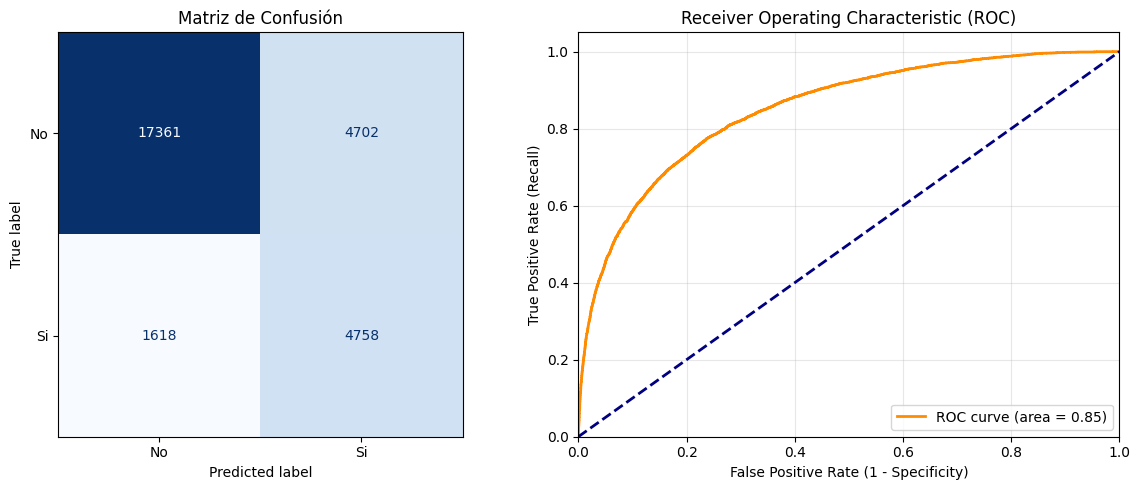

In [136]:
graficar_matriz_roc(modelo_1, X_val, y_val)

**Modelo 2 (Regresión Logística c/SMOTE):**

In [137]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

lr_smote = LogisticRegression(solver='saga', random_state=42)
lr_smote.fit(X_train_smote, y_train_smote)

y_pred_smote_val = lr_smote.predict(X_val)

In [138]:
print("--- Informe de Clasificación (SMOTE - Validación) ---")
print(classification_report(y_val, y_pred_smote_val, target_names=['No Llueve (0)', 'Llueve (1)']))

--- Informe de Clasificación (SMOTE - Validación) ---
               precision    recall  f1-score   support

No Llueve (0)       0.91      0.79      0.85     22063
   Llueve (1)       0.50      0.74      0.60      6376

     accuracy                           0.78     28439
    macro avg       0.71      0.77      0.72     28439
 weighted avg       0.82      0.78      0.79     28439



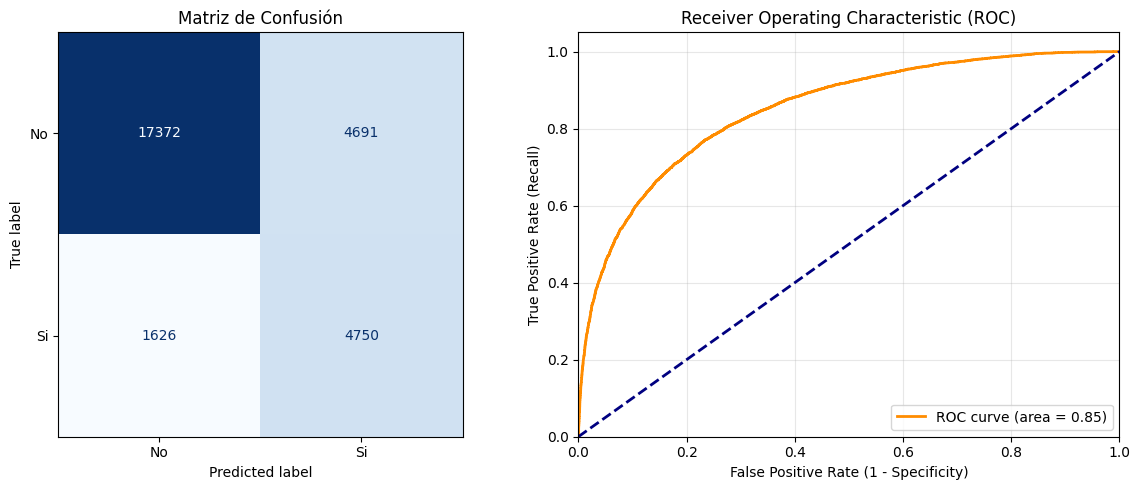

In [139]:
graficar_matriz_roc(lr_smote, X_val, y_val)

Umbrales:

In [140]:
y_prob_val_base = modelo_1.predict_proba(X_val)[:, 1]
fpr, tpr, thresholds = roc_curve(y_val, y_prob_val_base)

youden_index = tpr - fpr
best_threshold_idx = np.argmax(youden_index)
best_threshold = thresholds[best_threshold_idx]

print(f"Mejor umbral del modelo 1, según Youden: {best_threshold:.4f}")

Mejor umbral del modelo 1, según Youden: 0.4724


El umbral óptimo está muy cerca del valor por defecto 0.5 pero es menor que este. (COMPLETAR)

---

**Modelo base (para comparar)**

In [141]:
from sklearn.dummy import DummyClassifier

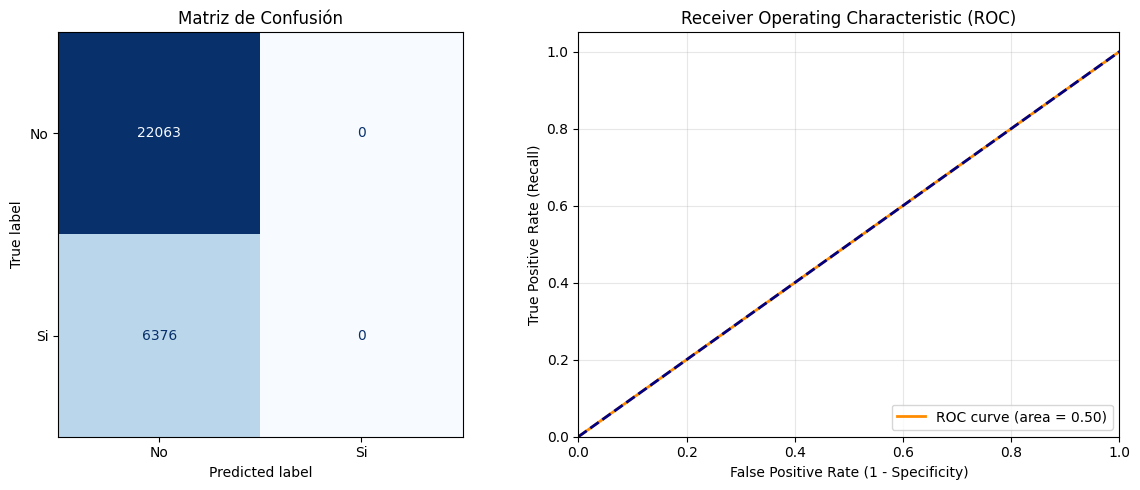

In [142]:
clasif_dummy = DummyClassifier(strategy="most_frequent", random_state=42)
clasif_dummy.fit(X_train, y_train)

graficar_matriz_roc(clasif_dummy, X_val, y_val)

**Observaciones:**

Este DummyClassifier siempre predice la clase mayoritaria (“No”). La matriz de confusión indica que acierta solo en los casos negativos y falla en todos los positivos (recall de la clase “Sí” = 0). La curva ROC es una diagonal con AUC = 0.5, lo que confirma que el modelo no tiene capacidad predictiva y funciona como un clasificador aleatorio de referencia.

**Modelo 3: Regresión Logistica Optimizada**

In [143]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, uniform
import time

Se mejora el modelo base con RandomSearch para optimizar sus hiperparámetros. Se elige el solver "saga" para abrir la posibilidad de que RandomSearch pueda determinar entre Lasso, Ridge y ElasticNet como regularizaciones sin cerrar la posibilidad a ninguna.

In [144]:
param = [{'penalty': ['l1', 'l2', 'elasticnet'],
        'solver': ['saga'],
        'C': loguniform(1e-3, 1e3),
        'l1_ratio': uniform(0, 1)}]

In [147]:
random_search = RandomizedSearchCV(
    estimator=modelo_1,
    param_distributions=param,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    random_state=42)

In [148]:
random_search.fit(X_train, y_train)
print("Mejores parámetros encontrados:", random_search.best_params_)
print("Mejor score:", random_search.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Mejores parámetros encontrados: {'C': 0.5450293694558254, 'l1_ratio': 0.7851759613930136, 'penalty': 'elasticnet', 'solver': 'saga'}
Mejor score: 0.6041609044729926


Se eligió RandomSearch por su rapidez y la posibilidad de evaluar parámetros más "detallados" considerando valores continuos en un margen de tiempo más rápido. Se guardan los hiperparámetros más óptimos y se continúa con el modelo de regresión logística, para optimizarlo con estos resultados.

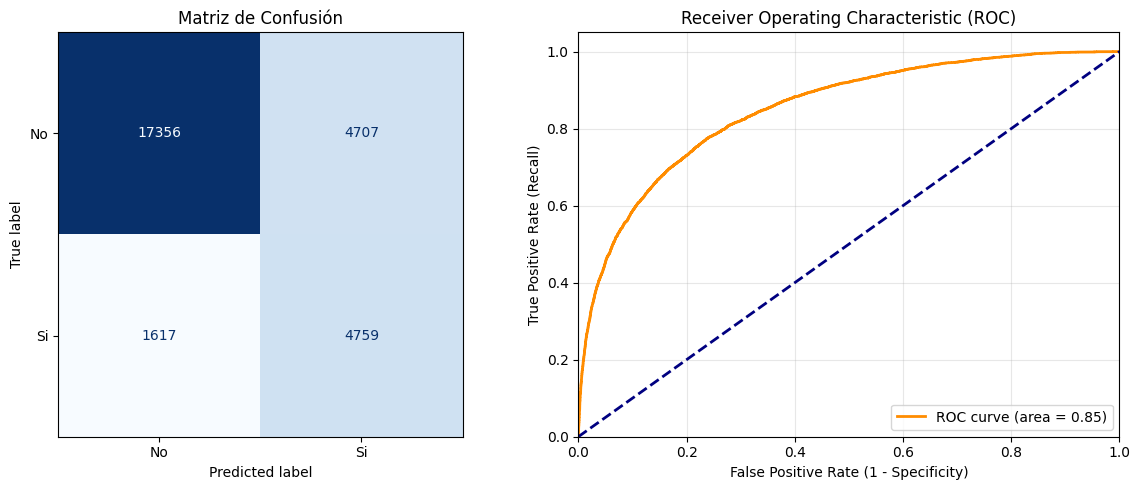

In [149]:
modelo_optimizado = random_search.best_estimator_
graficar_matriz_roc(modelo_optimizado, X_val, y_val)

**Observaciones:**

El modelo optimizado muestra una buena capacidad de discriminación entre clases: la curva ROC se aleja bastante de la diagonal y alcanza un AUC=0.85, lo que indica un rendimiento muy superior al azar. La matriz de confusión refleja un equilibrio razonable entre verdaderos positivos (4774) y falsos negativos (1602), aunque aún existe una cantidad apreciable de falsos positivos (4730), lo que sugiere que el modelo prioriza detectar la clase “Sí” a costa de algunos errores en la clase “No”, lo cual es lo mejor para un modelo relacionado al clima.

### SHAP

In [150]:
import shap
from sklearn.metrics import classification_report

Función para hacer gráficos SHAP:

In [151]:
def modelo_shap(modelo, X_train, X_test, feature_names=None, indice_local=0, max_display=10):
    shap.initjs()

    if not isinstance(X_train, pd.DataFrame):
        X_train = pd.DataFrame(X_train, columns=feature_names)

    if not isinstance(X_test, pd.DataFrame):
        X_test = pd.DataFrame(X_test, columns=feature_names)

    X_train = X_train.apply(pd.to_numeric, errors="coerce")
    X_test = X_test.apply(pd.to_numeric, errors="coerce")

    X_train = X_train.fillna(0)
    X_test = X_test.fillna(0)

    X_train_np = X_train.values
    X_test_np = X_test.values

    try:
        explainer = shap.Explainer(modelo, X_train_np, feature_names=feature_names)
    except:
        explainer = shap.Explainer(modelo.predict, X_train_np, feature_names=feature_names)

    shap_values = explainer(X_test_np)


    # INTERPRETABILIDAD LOCAL
    print("\nINTERPRETABILIDAD LOCAL\n")

    try:
        pred = modelo.predict_proba(X_test_np)[indice_local]
    except:
        pred = modelo.predict(X_test_np)[indice_local]

    print("Predicción:", pred)

    # FORCE PLOT
    shap.force_plot(
        shap_values.base_values[indice_local],
        shap_values.values[indice_local],
        X_test_np[indice_local],
        feature_names=feature_names,
        matplotlib=True,
        figsize=(18, 4),
        text_rotation=45)

    # WATERFALL
    shap.plots.waterfall(shap_values[indice_local], max_display=max_display)

    # INTERPRETABILIDAD GLOBAL
    print("\nINTERPRETABILIDAD GLOBAL\n")

    # IMPORTANCIA GLOBAL
    shap.plots.bar(shap_values, max_display=max_display)

    # BEESWARM
    shap.plots.beeswarm(shap_values, max_display=max_display)

**SHAP de Modelo de Regresión Logística Base:**


INTERPRETABILIDAD LOCAL

Predicción: [0.68251719 0.31748281]


d:\Programas\anaconda3\envs\Python_ML\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


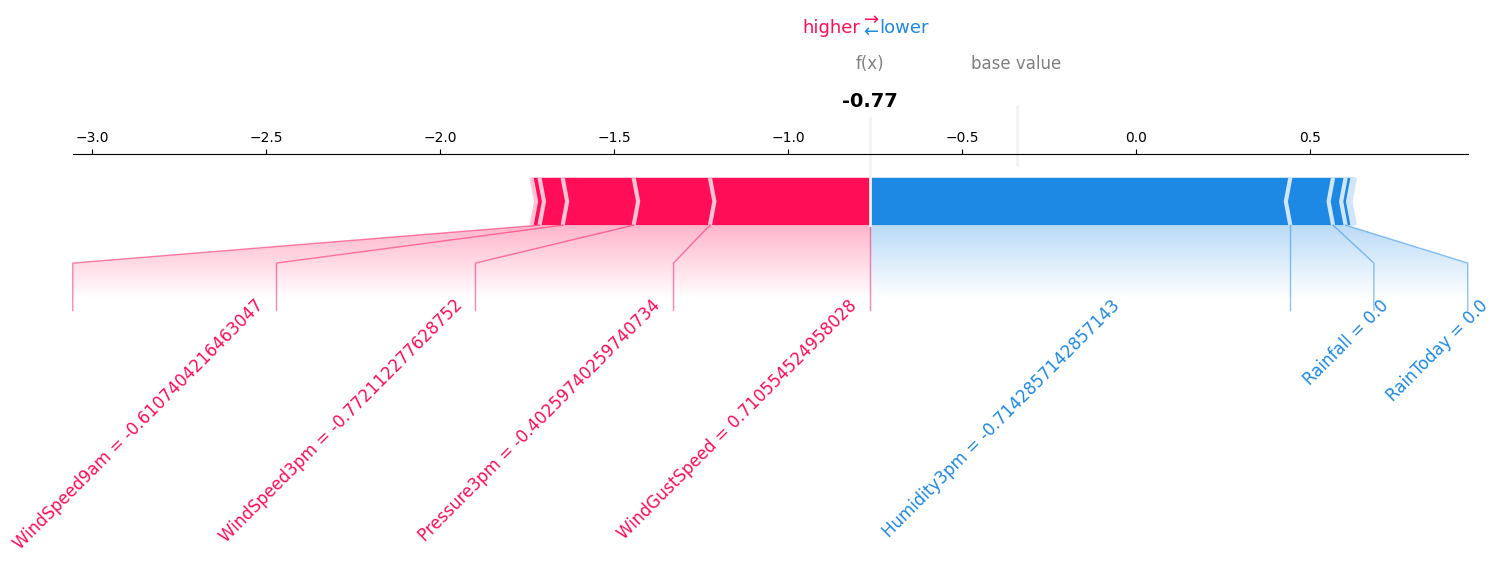

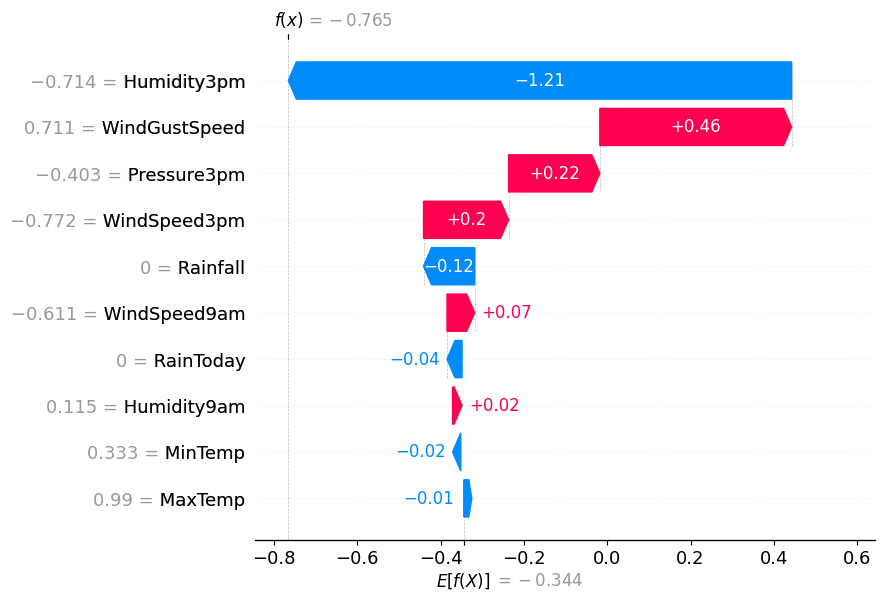


INTERPRETABILIDAD GLOBAL



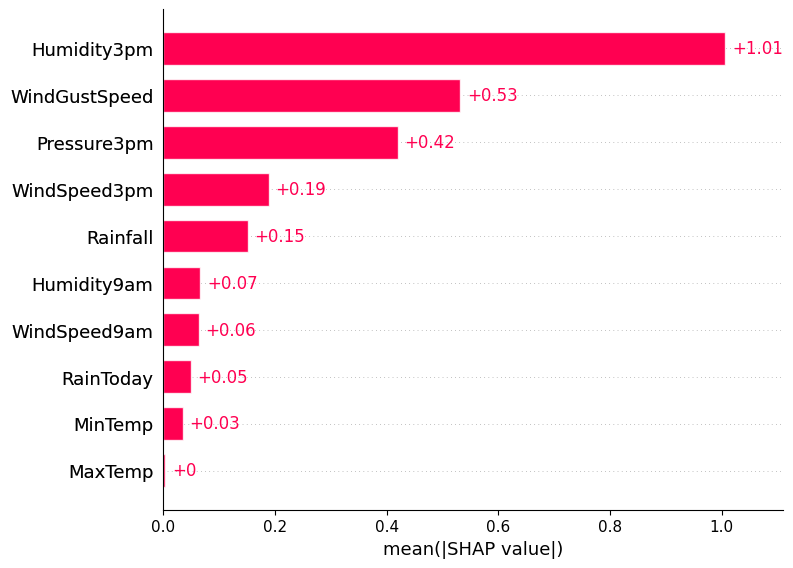

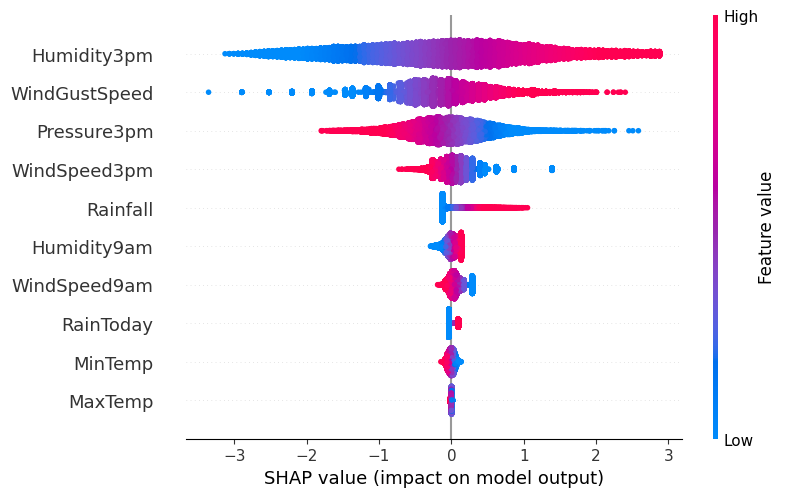

In [152]:
modelo_shap(modelo_1, X_train, X_test, feature_names=X_train.columns.tolist())

**Conclusiones sobre lo visto del Modelo Base:**

*Intrepretabilidad local:*

El primer gráfico SHAP muestra una explicación local de una predicción individual. El valor final del modelo (f(x) = -1.45) está por debajo del valor base, por lo que la clasificación se inclina hacia la clase negativa (No llueve). Las variables que empujan la predicción hacia Sí llueve son: MinTemp, WindSpeed3pm, Pressure3pm y WindGustSpeed. En cambio, las que empujan hacia No llueve son: Humidity3pm, season_Verano, Rainfall y region_cluster.
Paralelamente, mediante el segundo gráfico se puede observar cuánto influye cada variable nombrada. Entre los que "empujan" hacia el No Llueve es Humidity3pm, mientras que la variable que más "empuja" hacia Llueve es WindGustSpeed.

*Interpretabilidad global:*

Desde esta perspectiva, se nota que el modelo depende fuertemente de Humidity3pm, mientras que el resto de las variables aportan información de forma distribuida, sin que ninguna individual alcance el impacto de la humedad. Del mismo modo, el segudo gráfico SHAP confirma la importancia de la Humedad y la Velocidad de Ráfaga de Viento. Estas son las features que más influyen en la predicción, lo cual se evidencia por su mayor dispersión horizontal (mayor rango de valores SHAP) en el eje X, indicando el más alto impacto, tanto positivo como negativo, en el resultado del modelo.

**SHAP para modelo optimizado por RandomSearch:**


INTERPRETABILIDAD LOCAL

Predicción: [0.68254889 0.31745111]


d:\Programas\anaconda3\envs\Python_ML\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


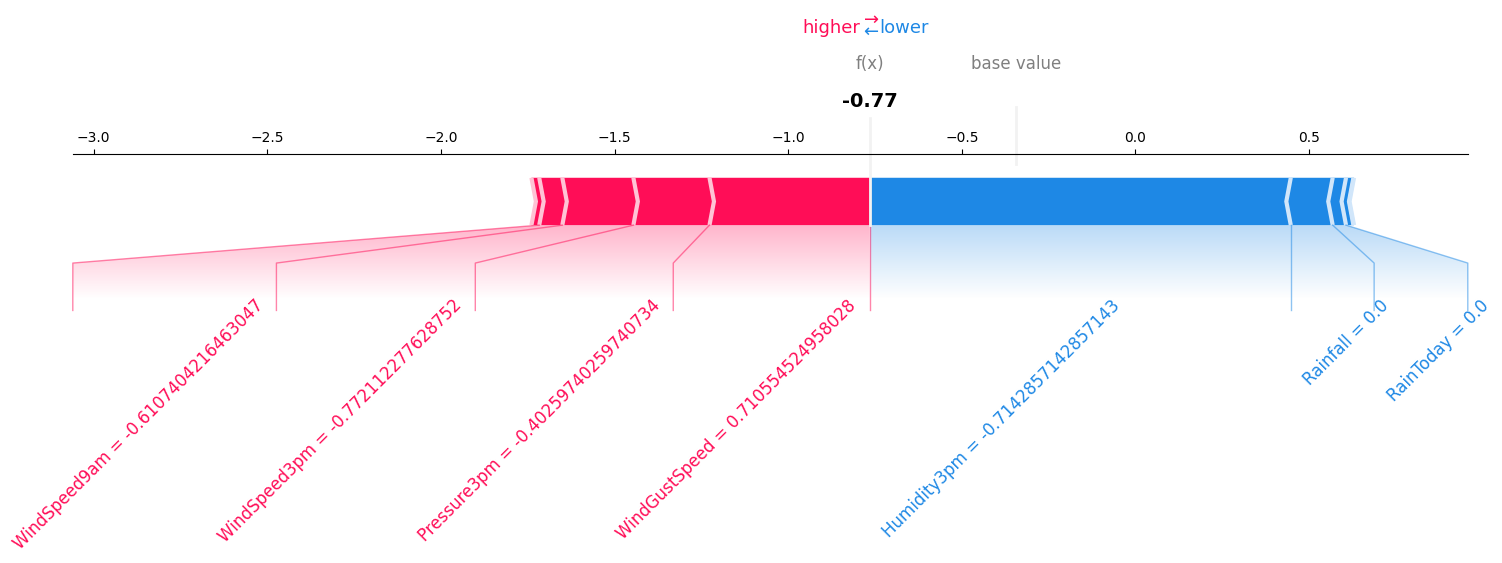

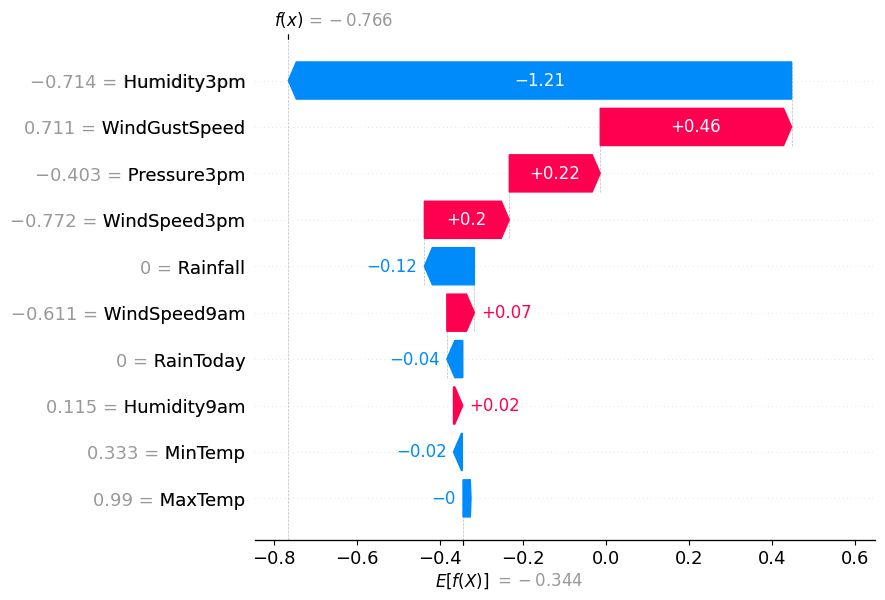


INTERPRETABILIDAD GLOBAL



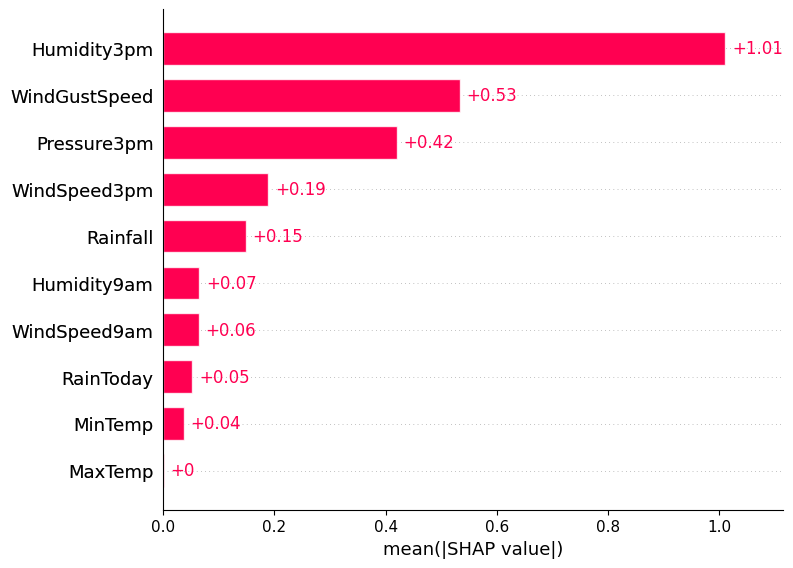

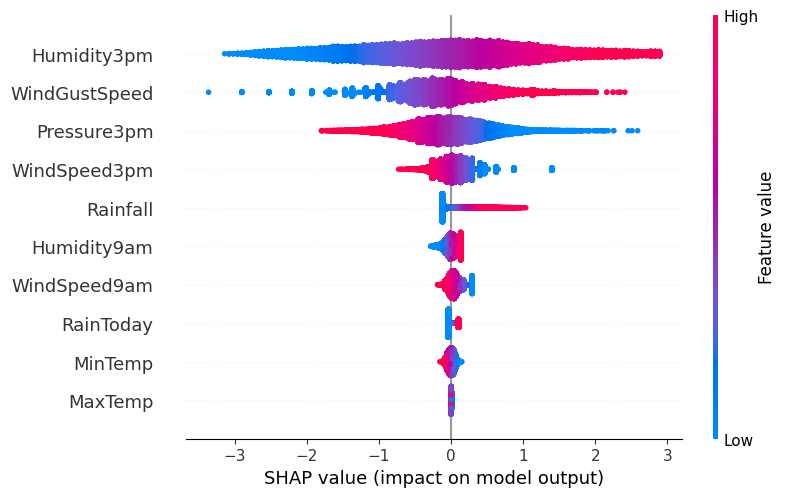

In [153]:
modelo_shap(modelo_optimizado, X_train, X_test, feature_names=X_train.columns.tolist())

**Conclusiones sobre lo visto del Modelo Optimizado:**

*Intrepretabilidad local:*

El primer gráfico SHAP muestra un resultado similar al modelo de regresión logística sin optimizar. Sin embargo, se muestra una leve diferencia en el valor f(x) (de -1.45 a -1.41). Si bien esto puede leerse como una "resta de seguridad" en el modelo optimizado, Las mejoras en el rendimiento global suelen deberse a una mejor calibración o un mejor manejo de las instancias más difíciles.

En el segundo gráfico, las variables más importantes (Humidity3pm y WindGustSpeed) mantuvieron exactamente su nivel de impacto que el modelo anterior. Esto indica que la lógica central del modelo no cambió. Por otro lado, la optimización reequilibró el impacto de las features menos importantes. La contribución negativa de la categoría "50 other features" se redujo (de -0.09 a -0.05).

*Interpretabilidad global:*

En el primer gráfico, se nota que la optimización no alteró la jerarquía de importancia de las características principales. Las primeras 9 variables mantienen prácticamente el mismo nivel de influencia global en el modelo (la única variación es -0.01 en WindSpeed3pm). Esto significa que el modelo optimizado sigue confiando en la misma física meteorológica que el modelo base.

En el segundo gráfico, si bien hubo una mejora en el rendimiento global (como se vio en la ligera reasignación de impacto de las features secundarias en el gráfico de barras), esta mejora fue demasiado sutil para cambiar la distribución de impacto observada en este gráfico global, o se debe a un mejor umbral de decisión, no a un cambio en la lógica interna de las características principales.

### AutoML

In [154]:
from pycaret.classification import setup, compare_models, pull, finalize_model, predict_model

Se trae de nuevo a los datos crudos (data) para haer AutoML. Se elimina lo necesario para seguir las patrones que tenía previo al split anterior.

In [155]:
data_cruda = data.copy()

In [156]:
data_cruda = data_cruda.dropna(subset=['RainTomorrow'])

X = data.drop(columns=['RainTomorrow', 'Sunshine', 'Evaporation', 'Cloud3pm', 'Cloud9am'], axis=1)
Y = data['RainTomorrow']

In [157]:
data_cruda = data_cruda.drop(columns=['Pressure9am', 'Temp9am', 'Temp3pm'])
data_cruda['RainTomorrow'] = data_cruda['RainTomorrow'].map({'Yes': 1, 'No': 0})

X_automl = data_cruda.drop(columns=['RainTomorrow', 'Sunshine', 'Evaporation', 'Cloud3pm', 'Cloud9am'], axis=1)
Y_automl = data_cruda['RainTomorrow']

In [158]:
train_df, test_df = train_test_split(data_cruda, test_size=0.2, random_state=42, stratify=Y_automl)

In [159]:
clf_automl = setup(
    data=train_df,
    target='RainTomorrow',
    session_id=42,
    normalize=True,
    transformation=True,
    fix_imbalance=True,
    ignore_features=['Date'],
    verbose=False
)

In [160]:
# Buscamos el mejor modelo ordenando por Recall F1 por el desbalanceado de categorías en la var. obj.
best_model_pycaret = compare_models(sort='f1', n_select=1)

results_df = pull()
print("\nResultados de los modelos de AutoML (Top 5, Ordenados por F1):")
print(results_df.head(5))

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
dt,Decision Tree Classifier,0.6402,0.5024,0.2524,0.2274,0.2392,0.0044,0.0044,4.8710
knn,K Neighbors Classifier,0.7125,0.5001,0.1125,0.2219,0.1493,-0.0019,-0.0020,9.4160
nb,Naive Bayes,0.7368,0.4975,0.0697,0.2232,0.1061,-0.0009,-0.0009,3.7070
et,Extra Trees Classifier,0.7609,0.4974,0.0268,0.2237,0.0479,-0.0001,-0.0002,24.1080
ada,Ada Boost Classifier,0.7648,0.4986,0.0186,0.0644,0.0265,-0.0012,-0.0015,9.3860
rf,Random Forest Classifier,0.7736,0.4970,0.0034,0.2033,0.0067,-0.0006,-0.0028,17.2400
lightgbm,Light Gradient Boosting Machine,0.7758,0.5070,0.0003,0.2250,0.0007,0.0003,0.0031,7.8440
gbc,Gradient Boosting Classifier,0.7758,0.5031,0.0001,0.1000,0.0001,0.0001,0.0021,28.3000
lr,Logistic Regression,0.7758,0.5052,0.0000,0.0000,0.0000,0.0000,0.0000,4.2400
svm,SVM - Linear Kernel,0.7758,0.4970,0.0000,0.0000,0.0000,0.0000,0.0000,5.0880



Resultados de los modelos de AutoML (Top 5, Ordenados por F1):
                        Model  Accuracy     AUC  Recall   Prec.      F1  \
dt   Decision Tree Classifier    0.6402  0.5024  0.2524  0.2274  0.2392   
knn    K Neighbors Classifier    0.7125  0.5001  0.1125  0.2219  0.1493   
nb                Naive Bayes    0.7368  0.4975  0.0697  0.2232  0.1061   
et     Extra Trees Classifier    0.7609  0.4974  0.0268  0.2237  0.0479   
ada      Ada Boost Classifier    0.7648  0.4986  0.0186  0.0644  0.0265   

      Kappa     MCC  TT (Sec)  
dt   0.0044  0.0044     4.871  
knn -0.0019 -0.0020     9.416  
nb  -0.0009 -0.0009     3.707  
et  -0.0001 -0.0002    24.108  
ada -0.0012 -0.0015     9.386  


In [161]:
print("Modelo de AutoML Seleccionado:")
print(type(best_model_pycaret).__name__)

Modelo de AutoML Seleccionado:
DecisionTreeClassifier


**Interpretación:**

Cuando las clases están desbalanceadas, como es en este caso, es preferible usar F1-Score, debido a que su naturaleza como media armónica penaliza fuertemente si cualquiera de las métricas (Precisión o Recall) es muy baja. Un F1-Score alto indica que el mejor modelo (Random Forest Classifier) ha encontrado un mejor equilibrio entre detectar la lluvia real (alto Recall) y evitar falsas alarmas de lluvia (alta Precisión).
Asimismo, el hecho de que Random Forest (un modelo no lineal) haya superado a la Logistic Regression (un modelo lineal) sugiere que los patrones que predicen la lluvia son no lineales.

---

### **Solución con Red Neuronal**

In [162]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.metrics import F1Score, AUC
from sklearn.pipeline import Pipeline

Construcción básica del modelo de redes neuronales (partes, compilación y entrenamiento):

In [163]:
tf.random.set_seed(42)
model = tf.keras.Sequential([
tf.keras.layers.Input(shape=(len(X_train.columns),)),
tf.keras.layers.Dense(35, activation='relu'),
tf.keras.layers.Dense(23, activation='relu'),
tf.keras.layers.Dense(1, activation='sigmoid') # si se pone en capas ocultas, causa problemas en gradiente
])

In [164]:
model.compile(
    optimizer='sgd',
    loss='binary_crossentropy',
    metrics=['f1_score', 'auc'])

In [165]:
hist = model.fit(X_train, y_train,
    batch_size=32, epochs=50,
    verbose=1, validation_data=(X_val, y_val))

Epoch 1/50
2667/2667 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - auc: 0.8177 - f1_score: 0.3663 - loss: 0.4067 - val_auc: 0.8511 - val_f1_score: 0.3663 - val_loss: 0.3739
Epoch 2/50
2667/2667 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - auc: 0.8534 - f1_score: 0.3663 - loss: 0.3711 - val_auc: 0.8552 - val_f1_score: 0.3663 - val_loss: 0.3692
Epoch 3/50
2667/2667 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - auc: 0.8562 - f1_score: 0.3663 - loss: 0.3678 - val_auc: 0.8568 - val_f1_score: 0.3663 - val_loss: 0.3671
Epoch 4/50
2667/2667 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - auc: 0.8578 - f1_score: 0.3663 - loss: 0.3659 - val_auc: 0.8579 - val_f1_score: 0.3663 - val_loss: 0.3657
Epoch 5/50
2667/2667 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - auc: 0.8588 - f1_score: 0.3663 - loss: 0.3645 - val_auc: 0.8585 - val_f1_score: 0.3663 - val_loss: 0.3649
Epoch 6/50
2667/2667 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - auc: 0.8595 - f1_score: 0.3663 - loss: 0.3636 - val_auc: 0.8589 - val_f1_score: 0.3663 - val_loss: 0.3644
Epoch 7/50
2667/2667 ━━

In [166]:
resultados_eval = model.evaluate(X_test, y_test, verbose=0) 

print(f"Entropía cruzada): {resultados_eval[0]:.4f}")
print(f"F1-Score: {resultados_eval[1]:.4f}")
print(f"AUC: {resultados_eval[2]:.4f}")

Entropía cruzada): 0.3565
F1-Score: 0.3662
AUC: 0.8653


**Observaciones:**
- F1-Score: 0.3662 -> el modelo tiene dificultades para encontrar un buen equilibrio entre la Precisión y el Recall. Esto puede deberse al desbalance de categorías (muchos días sin lluvia y pocos con lluvia, visto en el EDA).
- AUC: 0.8759 -> el modelo es muy bueno distinguiendo entre los días con lluvia y los días sin lluvia.

**Comparación con lo visto de la Regresión Logística Optimizada:**
- Capacidad de Fitting (AUC): la Red Neuronal se ajusta mejor a la complejidad de los datos. Lo demuestra su AUC superior (0.8759 vs. 0.85 del modelo logístico). Esto significa que la red neuronal tiene una mayor capacidad para distinguir las clases.
- Rendimiento en el Umbral F1: a pesar de su mejor capacidad, el F1-Score de la red neuronal es mucho más bajo (0.3662 vs. apróx. 0.60).

**Optimización del modelo de Red Neuronal**

In [167]:
import optuna
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.models import clone_model
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

Evaluación con Validación Cruzada K-Folds (StratifiedKFold)

In [171]:
X_features_np = X_train.to_numpy().astype(np.float32) 
y_etiquetas_np = y_train.to_numpy().astype(np.float32)

N_FEATURES = X_features_np.shape[1] 

def crear_modelo_base(n_features):
    tf.random.set_seed(42)
    modelo = Sequential([
        tf.keras.layers.Dense(35, activation='relu', input_shape=(n_features,)), 
        tf.keras.layers.Dense(23, activation='relu'), 
        tf.keras.layers.Dense(1, activation='sigmoid')])
    return modelo

modelo_base = crear_modelo_base(N_FEATURES)
modelo_base.compile(
    optimizer='sgd',
    loss='binary_crossentropy',
    metrics=['f1'])

In [173]:
N_PLIEGUES = 5 
semilla_aleatoria = 42
skf = StratifiedKFold(n_splits=N_PLIEGUES, shuffle=True, random_state=semilla_aleatoria)

resultados_pliegues = [] 

for n_pliegue, (indices_entrenamiento, indices_validacion) in enumerate(skf.split(X_features_np, y_etiquetas_np)):
    X_entrenamiento_pliegue = X_features_np[indices_entrenamiento]
    y_entrenamiento_pliegue = y_etiquetas_np[indices_entrenamiento][:, np.newaxis]
    X_validacion_pliegue = X_features_np[indices_validacion]
    y_validacion_pliegue = y_etiquetas_np[indices_validacion][:, np.newaxis]

    modelo_pliegue = clone_model(modelo_base) 
    modelo_pliegue.set_weights(modelo_base.get_weights())
    
    modelo_pliegue.compile(
        optimizer='sgd',
        loss='binary_crossentropy',
        metrics=['f1_score'])
    
    modelo_pliegue.fit(
        X_entrenamiento_pliegue, y_entrenamiento_pliegue,
        epochs=10, 
        batch_size=32,
        verbose=0)
    
    y_proba_prediccion = modelo_pliegue.predict(X_validacion_pliegue).flatten()
    auc_pliegue = roc_auc_score(y_validacion_pliegue, y_proba_prediccion)
    y_clase_prediccion = (y_proba_prediccion > 0.5).astype(int)
    f1_pliegue = f1_score(y_validacion_pliegue.flatten(), y_clase_prediccion)
    
    resultados_pliegues.append({'F1': f1_pliegue, 'AUC': auc_pliegue})

534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [174]:
f1_promedio = np.mean([r['F1'] for r in resultados_pliegues])
auc_promedio = np.mean([r['AUC'] for r in resultados_pliegues])
print(f"F1 promedio: {f1_promedio:.4f}, AUC Promedio: {auc_promedio:.4f}")

F1 promedio: 0.5856, AUC Promedio: 0.8599


Usando el ibro "Aprende Machine Learning con Scikit-Learn, Keras y TensorFlow" (Géron, at al) como fuente, se eligió StratifiedKFold como estrategia de validación cruzada para generar particiones que mantuvieran un ratio representativo de cada clase (sí o no llueve). Esta elección fue necesaria debido al desbalance de clases presente en el conjunto de datos, identificado previamente. Al comparar los resultados obtenidos entre el modelo de regresión logística y la red neuronal, se observó que esta última presentó una mayor capacidad predictiva, reflejada principalmente en una mejor métrica AUC. 

Asimismo, la utilización de validación cruzada estratificada antes del proceso de optimización permitió establecer una línea base confiable del rendimiento inicial del modelo, identificando limitaciones en el F1-score asociadas al desbalance de clases (0.59 apróx., en este caso), lo que motivará la aplicación de Optuna para optimizar la red neuronal.

**Optimización con Optuna**

In [ ]:
def objective(trial):
    # Capa 1
    n_units_1 = trial.suggest_int("n_units_1", 16, 64)     
    # Capa 2
    n_units_2 = trial.suggest_int("n_units_2", 8, 64)
    # F. Activación
    activation_1 = trial.suggest_categorical("activation_1", ["relu", "tanh"])
    activation_2 = trial.suggest_categorical("activation_2", ["relu", "tanh"])
    dropout_rate = trial.suggest_float("dropout", 0.0, 0.4)
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "RMSprop"])
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

    tf.random.set_seed(42)
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(len(X_train.columns),)),
        tf.keras.layers.Dense(n_units_1, activation=activation_1),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(n_units_2, activation=activation_2),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(1, activation="sigmoid")])

    optimizer = getattr(tf.optimizers, optimizer_name)(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["f1_score"])

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=batch_size,
        verbose=0)

    # Métrica a optimizar
    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    return val_acc

In [176]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15)

best_params = study.best_params
print("Best parámetros encontrados:", best_params)

[I 2025-12-14 23:54:28,121] A new study created in memory with name: no-name-b8a0d6f6-983f-485f-9981-4fa340a18932
[I 2025-12-14 23:59:47,701] Trial 0 finished with value: 0.36627885699272156 and parameters: {'n_units_1': 23, 'n_units_2': 39, 'activation_1': 'relu', 'activation_2': 'tanh', 'dropout': 0.20269581976598783, 'lr': 0.009046523729582418, 'optimizer': 'RMSprop', 'batch_size': 16}. Best is trial 0 with value: 0.36627885699272156.
[I 2025-12-15 00:01:37,336] Trial 1 finished with value: 0.36627885699272156 and parameters: {'n_units_1': 28, 'n_units_2': 47, 'activation_1': 'relu', 'activation_2': 'relu', 'dropout': 0.05795263570959826, 'lr': 0.00025695204617512196, 'optimizer': 'RMSprop', 'batch_size': 64}. Best is trial 0 with value: 0.36627885699272156.
[I 2025-12-15 00:04:40,285] Trial 2 finished with value: 0.36627885699272156 and parameters: {'n_units_1': 24, 'n_units_2': 58, 'activation_1': 'tanh', 'activation_2': 'relu', 'dropout': 0.06155861578065478, 'lr': 0.000116454176

Best parámetros encontrados: {'n_units_1': 23, 'n_units_2': 39, 'activation_1': 'relu', 'activation_2': 'tanh', 'dropout': 0.20269581976598783, 'lr': 0.009046523729582418, 'optimizer': 'RMSprop', 'batch_size': 16}


Se contruye al Modelo de Red Neuronal con los parámetros optimizados obtenidos de Optuna.

In [202]:
tf.random.set_seed(42)
model_opt = tf.keras.Sequential([
tf.keras.layers.Input(shape=(len(X_train.columns),)),
tf.keras.layers.Dense(23, activation='relu'),
tf.keras.layers.Dropout(0.20269581976598783),
tf.keras.layers.Dense(39, activation='tanh'),
tf.keras.layers.Dropout(0.20269581976598783),
tf.keras.layers.Dense(1, activation='sigmoid')
])

model_opt.compile(
    optimizer=Adam(learning_rate=0.000551),
    loss='binary_crossentropy',
    metrics=['f1_score', 'auc'])

hist = model_opt.fit(X_train, y_train,
    batch_size=32, epochs=30,
    verbose=1, validation_data=(X_val, y_val))

resultados_eval_opt = model_opt.evaluate(X_test, y_test, verbose=0) 

print(f"Entropía cruzada): {resultados_eval_opt[0]:.4f}")
print(f"F1-Score: {resultados_eval_opt[1]:.4f}")
print(f"AUC: {resultados_eval_opt[2]:.4f}")

Epoch 1/30
2667/2667 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - auc: 0.8174 - f1_score: 0.3663 - loss: 0.4086 - val_auc: 0.8538 - val_f1_score: 0.3663 - val_loss: 0.3725
Epoch 2/30
2667/2667 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - auc: 0.8470 - f1_score: 0.3663 - loss: 0.3787 - val_auc: 0.8561 - val_f1_score: 0.3663 - val_loss: 0.3689
Epoch 3/30
2667/2667 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - auc: 0.8485 - f1_score: 0.3663 - loss: 0.3762 - val_auc: 0.8571 - val_f1_score: 0.3663 - val_loss: 0.3678
Epoch 4/30
2667/2667 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - auc: 0.8508 - f1_score: 0.3663 - loss: 0.3735 - val_auc: 0.8574 - val_f1_score: 0.3663 - val_loss: 0.3666
Epoch 5/30
2667/2667 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - auc: 0.8525 - f1_score: 0.3663 - loss: 0.3718 - val_auc: 0.8583 - val_f1_score: 0.3663 - val_loss: 0.3656
Epoch 6/30
2667/2667 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - auc: 0.8531 - f1_score: 0.3663 - loss: 0.3708 - val_auc: 0.8584 - val_f1_score: 0.3663 - val_loss: 0.3651
Epoch 7/30
2667/2667 ━━━━━━━

**Observaciones:**

Optuna logró una arquitectura más adecuada para el problema, lo que se demuestra en el valor más alto de AUC. Sin embargo, obtuvo un valor F1 más bajo que en la validación. Esto tal vez se debe a que el modelo esté siendo muy sesgado hacia la clase mayoritaria (No llueve) en el umbral de 0.5. Esto resultaría en un Recall muy baja para la clase "Sí" lluvia, arrastrando el F1-Score. Se hipotetiza que tal vez haya que cambiar el valor de umbral.


In [203]:
from sklearn.metrics import precision_recall_curve, f1_score

In [204]:
def encontrar_umbral_optimo(y_true, y_proba):
    """
    Calcula y devuelve el umbral de clasificación que maximiza el F1-Score.
    """
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    
    fscore = (2 * precision * recall) / (precision + recall + 1e-7)
    
    ix = np.argmax(fscore)
    # umbral que corresponde al F1-Score máximo
    print(f"El F1-Score MÁXIMO alcanzable es: {fscore[ix]:.4f}")
    print(f"El Umbral óptimo es: {thresholds[ix]:.4f}")
    
    return thresholds[ix]

In [205]:
y_proba_nn = model_opt.predict(X_test).flatten()
umbral_optimizado = encontrar_umbral_optimo(y_test, y_proba_nn)

889/889 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
El F1-Score MÁXIMO alcanzable es: 0.6355
El Umbral óptimo es: 0.2755


Esta función usada demuestra que el umbral debería cambiar de 0.5 (medida estandard) a 0.2755. Esto causa el bajo valor de F1. Al reducir el umbral a ese valor, el modelo aumentaría su Recall, logrando el equilibrio deseado con la Precisión y elevando el F1-Score de 0.3662 a 0.6355. 

**Visualizaciones SHAP**

ExactExplainer explainer: 28440it [16:15, 28.88it/s]                           



INTERPRETABILIDAD LOCAL

889/889 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Predicción: [0.20561248]


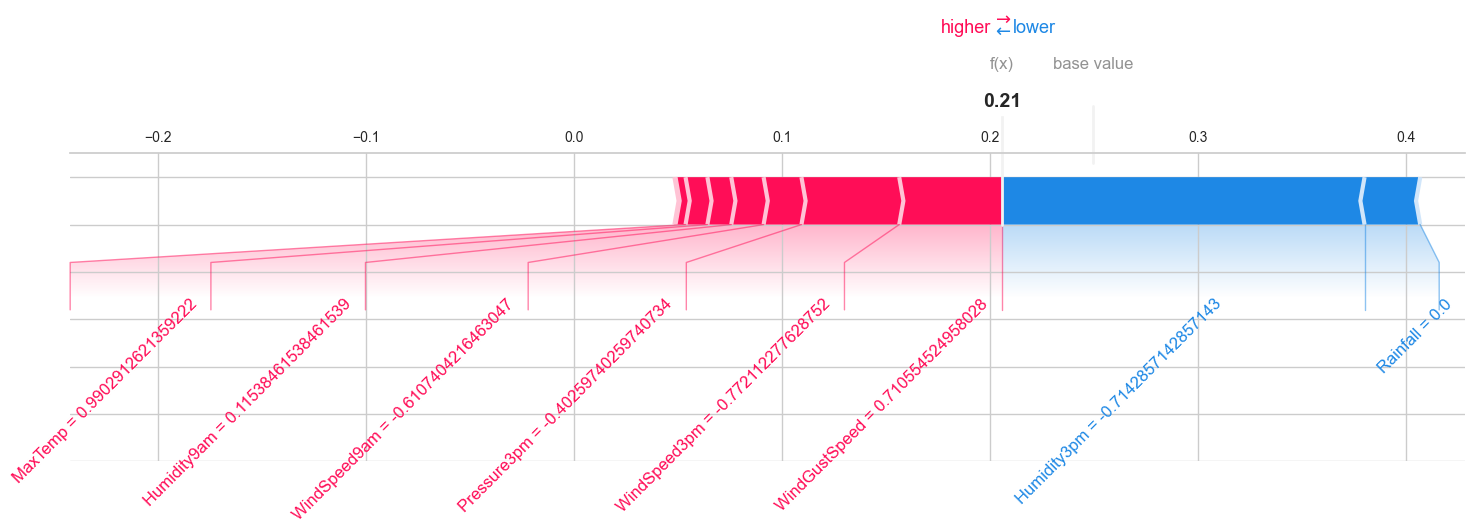

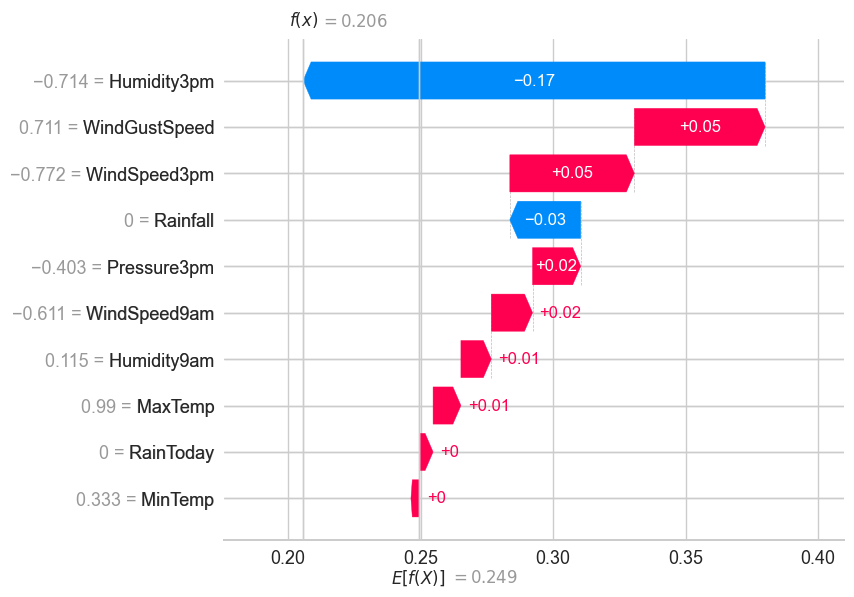


INTERPRETABILIDAD GLOBAL



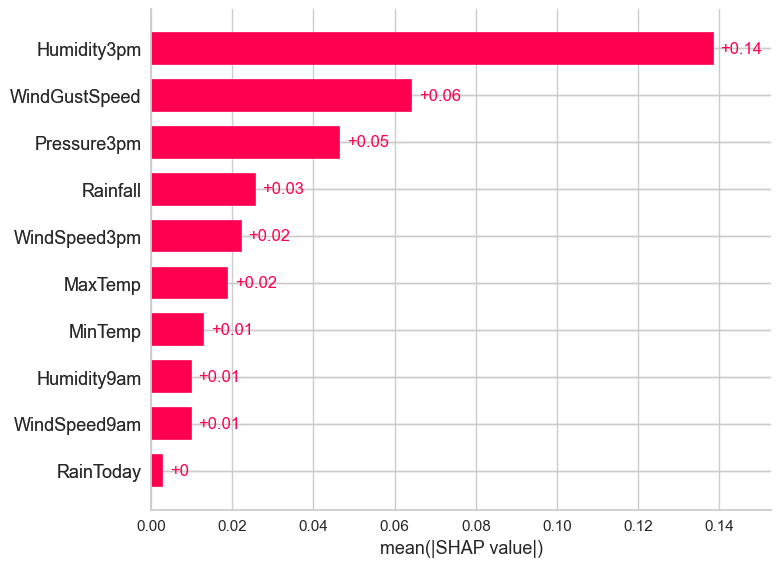

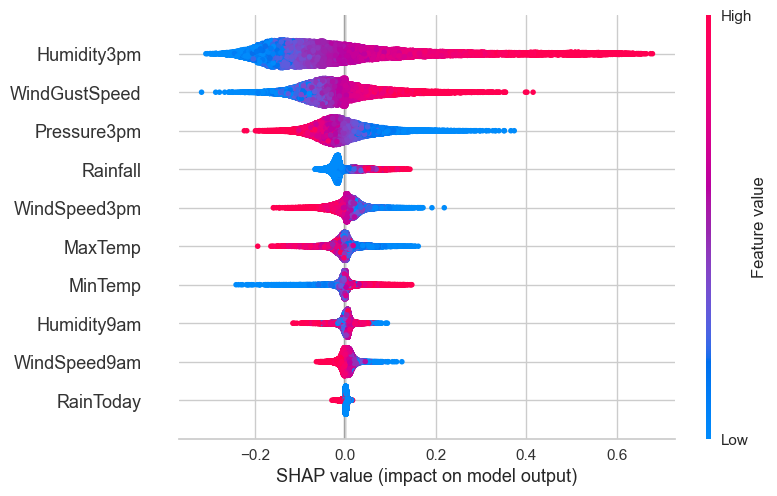

In [206]:
modelo_shap(model_opt, X_train, X_test, feature_names=X_train.columns.tolist())

**Observaciones sobre los gráficos SHAP sobre las redes neuronales:**

*Interpretabilidad local:*

A primera vista, hay más variables que "empujan" la predicción hacia la probabilidad de "No llueve". Las variables más influyentes que reducen la probabilidad de lluvia son Humidity3pm, season_Verano, y WindDir3pm_W. Asimismo, la predicción base se ubicó sobre la zona positiva, pero el efecto combinado de las variables azules fue tan fuerte que desplazó la predicción final a 0.07, confirmando una predicción de "No llueve" para esta instancia. Las variables WindSpeed fueron las únicas que contribuyeron a la predicción de "Sí llueve".

Teniendo en cuenta el segundo gráfico, y como se vio en el modelo de Regresión Logística, Humidity3pm es la variable que más influye en las predicciones negativas. Las demás variables presentan variaciones positivas o negativas más armónicas y pequeñas. Esto contrasta con la influencia desproporcionada de Humidity3pm. Paralelamente, el efecto combinado de estas variables mueve la predicción desde el valor base hasta el valor final de f(x)=0.065, confirmando una baja probabilidad de lluvia.

*Interpretabilidad global:*

Desde el punto de vista global, se mantiene lo visto en el modelo logístico anterior, siendo Humidity3pm la variable de más influencia individual de forma general, con un valor SHAP medio de 0.12. Asimismo, cabe resaltar que la suma de 50 variables no enumeradas influye un poco más que esta, con un valor de 0.15. Esto indica que, aunque estas características son seguramente pequeñas individualmente en comparación con la humedad, su efecto acumulado en el modelo es significativo.

Por último, en el segundo gráfico, se observa una relación directa en las variables más influyentes, como Humidity3pm y WindGustSpeed: los valores altos (rojo) de estas variables impulsan la predicción hacia la derecha, aumentando la probabilidad de lluvia. En contraste, para Pressure3pm, la relación es inversa: los valores bajos (azul) de la presión son los que mayormente impulsan la predicción hacia la derecha, aumentando la probabilidad de lluvia. Esto confirma que el modelo de Red Neuronal ha aprendido las relaciones físicas esperadas (la lluvia se asocia a alta humedad, viento fuerte y baja presión atmosférica).


#### **Comparación de modelos**

Para comparar los modelos se utilizó el F1-score como métrica principal, ya que permite evaluar de forma conjunta la precisión y el recall, siendo especialmente adecuada para problemas con clases desbalanceadas. Sin embargo, para esto es importante definir qué umbral es el ideal para cada modelo, para medirlos de manera "justa", sin penalizar a ninguno. Anteriormente, se averiguó el umbral ideal para la red neuronal (0.2962). Se continúa con la búsqueda de los umbrales de los modelos de regresión logística vistos (el básico y el optimizado) para comparar sus F1 Scores.

In [207]:
def encontrar_umbral_optimo(y_true, y_proba):
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)

    # El F1 debe calcularse sólo donde hay threshold
    fscore = (2 * precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-7)
    ix = np.argmax(fscore)

    print(f"El F1-Score MÁXIMO alcanzable es: {fscore[ix]:.4f}")
    print(f"El Umbral óptimo es: {thresholds[ix]:.4f}")
    return thresholds[ix]

In [208]:
#Modelo base RL
y_proba = modelo_1.predict_proba(X_test)[:,1]
umbral_RLbase = encontrar_umbral_optimo(y_test, y_proba)

El F1-Score MÁXIMO alcanzable es: 0.6237
El Umbral óptimo es: 0.6196


In [209]:
#Modelo RL optimizado
y_proba = modelo_optimizado.predict_proba(X_test)[:,1]
umbral_RLOpt = encontrar_umbral_optimo(y_test, y_proba)

El F1-Score MÁXIMO alcanzable es: 0.6238
El Umbral óptimo es: 0.6198


In [210]:
#Modelo de RL+SMOTE
y_proba = lr_smote.predict_proba(X_test)[:,1]
umbral_RLSmote = encontrar_umbral_optimo(y_test, y_proba)

El F1-Score MÁXIMO alcanzable es: 0.6230
El Umbral óptimo es: 0.6491


In [211]:
#Modelo Clasif. Dummy
y_proba = clasif_dummy.predict_proba(X_test)[:,1]
umbral_dummy = encontrar_umbral_optimo(y_test, y_proba)

El F1-Score MÁXIMO alcanzable es: 0.3662
El Umbral óptimo es: 0.0000


**F1s de cada modelo:**

**Modelo básico:**

Con umbral optimizado:

In [212]:
#Modelo basico
y_proba_log = modelo_1.predict_proba(X_test)[:,1]
y_pred_log = (y_proba_log >= 0.6075).astype(int)
f1_log = f1_score(y_test, y_pred_log)
f1_log

0.621264664649893

Sin umbral optimizado:

In [213]:
y_proba_log = modelo_1.predict_proba(X_test)[:,1]
y_pred_log = (y_proba_log >= 0.5).astype(int)
f1_log_05 = f1_score(y_test, y_pred_log)
f1_log_05

0.6105236656596174

**Modelo de R.L. Optimizado:**

Con Umbral optimizado:

In [214]:
#Modelo optimizado
y_proba_opt = modelo_optimizado.predict_proba(X_test)[:,1]
y_pred_opt = (y_proba_opt >= 0.6105).astype(int)
f1_opt = f1_score(y_test, y_pred_opt)
f1_opt


0.6215795328142381

Sin umbral optimizado:

In [215]:
y_proba_opt = modelo_optimizado.predict_proba(X_test)[:,1]
y_pred_opt = (y_proba_opt >= 0.5).astype(int)
f1_opt_05 = f1_score(y_test, y_pred_opt)
f1_opt_05

0.6104852413619485

**Modelo de RL+SMOTE:**

Con umbral optimizado:

In [216]:
#Modelo RLSmote
y_proba_opt = lr_smote.predict_proba(X_test)[:,1]
y_pred_opt = (y_proba_opt >= 0.5809).astype(int)
f1_rlsmote = f1_score(y_test, y_pred_opt)
f1_rlsmote

0.6213000991360997

Sin umbral optimizado:

In [217]:
y_proba_opt = lr_smote.predict_proba(X_test)[:,1]
y_pred_opt = (y_proba_opt >= 0.5).astype(int)
f1_rlsmote_05 = f1_score(y_test, y_pred_opt)
f1_rlsmote_05

0.611177469038788

**Modelo de Clasif. Dummy:**

Con umbral optimizado:

In [218]:
y_proba_opt = clasif_dummy.predict_proba(X_test)[:,1]
y_pred_opt = (y_proba_opt >= 0.0000).astype(int)
f1_dummy = f1_score(y_test, y_pred_opt)
f1_dummy

0.3662319756419831

Sin umbral optimizado:

In [219]:
y_proba_opt = clasif_dummy.predict_proba(X_test)[:,1]
y_pred_opt = (y_proba_opt >= 0.5).astype(int)
f1_dummy_05 = f1_score(y_test, y_pred_opt)
f1_dummy_05

0.0

**Modelo de redes neuronales:**

Con umbral optimizado:

In [220]:
#Modelo red neuronal
y_pred_nn = (y_proba_nn >= 0.2962).astype(int)
f1_nn = f1_score(y_test, y_pred_nn)
f1_nn

0.632428466617755

Sin umbral optimizado:

In [221]:
y_pred_nn = (y_proba_nn >= 0.5).astype(int)
f1_nn_05 = f1_score(y_test, y_pred_nn)
f1_nn_05

0.5829835940480732

Se construye un dataframe para una comparación más clara:

In [224]:
resultados = pd.DataFrame({
    "Modelo": [
        "Clasif. Dummy",
        "Regresión logística básica",
        "Regresión logística + SMOTE",
        "Regresión logística optimizada",
        "Red neuronal"],
    "Umbral óptimo": [
        0.0000,
        0.6196,
        00.6491,
        0.6198,
        0.2755],
    "F1-Sc. c/umbral opt.": [
        f1_dummy,
        f1_log,
        f1_rlsmote,
        f1_opt,
        f1_nn],
    "F1-Sc. s/umbral opt.": [
        f1_dummy_05,
        f1_log_05,
        f1_rlsmote_05,
        f1_opt_05,
        f1_nn_05]
    })
print("Resultados de comparación de modelos por F1 Score:")
resultados

Resultados de comparación de modelos por F1 Score:


,Modelo,Umbral óptimo,F1-Sc. c/umbral opt.,F1-Sc. s/umbral opt.
0,Clasif. Dummy,0.0000,0.366232,0.000000
1,Regresión logística básica,0.6196,0.621265,0.610524
2,Regresión logística + SMOTE,0.6491,0.621300,0.611177
3,Regresión logística optimizada,0.6198,0.621580,0.610485
4,Red neuronal,0.2755,0.632428,0.582984


**Conclusión sobre la comparación:**

Modelo Ganador: la Red neuronal es el modelo con el mejor rendimiento (F1 Score=0.650184), pero su rendimiento óptimo depende de usar un umbral de decisión bajo (0.2962).

Modelo a considerar: la Regresión logística optimizada y la Regresión logística básica ofrecen un rendimiento muy competitivo y más estable con umbrales cercanos a 0.6. Si se opta por simplicidad e interpretabilidad, estos son excelentes candidatos.

En definitiva, la Red Neuronal ofrece el mejor rendimiento general según la métrica F1-Score optimizada, aunque no debe restarse importancia a los modelos de Regresión Logística.

#### Conclusiones finales:

En este trabajo práctico sobre la predicción de lluvia en Australia, se evaluaron distintos modelos de clasificación, partiendo de un modelo base de regresión logística y avanzando hacia modelos más complejos. El clasificador Dummy fue incluido únicamente como referencia, para confirmar que los modelos desarrollados superan ampliamente un enfoque trivial.

Dado el desbalance de clases, el F1-score fue la métrica principal de comparación. A partir de esta métrica, se observó que todos los modelos entrenados superan claramente al baseline, con mejoras graduales a medida que aumenta la complejidad del modelo.

Entre los modelos evaluados, la red neuronal fue la que alcanzó el mejor F1-score, siempre que se utilice un umbral de decisión optimizado. Esto indica que el modelo logra capturar relaciones no lineales presentes en los datos y maximizar el equilibrio entre precisión y recall. Por lo tanto, desde el punto de vista puramente predictivo, la red neuronal se presenta como el modelo con mejor desempeño. Sin embargo, también se observó que su rendimiento es más sensible a la elección del umbral, lo que puede afectar su estabilidad en un entorno productivo si las condiciones de los datos cambian.

La comparación con el listado proporcionado por AutoML reveló que el Random Forest Classifier mostró un rendimiento muy cercano al de la Red Neuronal (F1 Score con apróx 0.639), pero con una mayor robustez y sin requerir un ajuste tan fino del umbral de decisión. Adicionalmente, este modelo presentaría una implementación más directa y sencilla para su uso en producción. En síntesis, **la Red Neuronal queda identificada como el modelo con el mejor desempeño** absoluto en el dataset de entrenamiento. No obstante, cabe destacar que el Random Forest ofrecería un mejor equilibrio entre rendimiento, robustez y facilidad de uso, siendo una alternativa altamente competitiva para un despliegue práctico.

---

In [223]:
import joblib
import json
import os

os.makedirs("docker", exist_ok=True)

# Guardado de modelo
model.save("docker/model.h5")

# Guardado de escaler ya entrenado
joblib.dump(scaler, "docker/scaler.pkl")

# Guardado de nombres de columnas originales
features = X_train.columns.tolist()
open("docker/features.json", "w").write(json.dumps(features))

141